# Gauss's principle of least constraint enables neural solution of forward and inverse dynamics


A key challenge in sensorimotor neuroscience is figuring out how the brain controls/adapts movement in real time, since **_sensory feedback is often too slow_** for fast actions. Most believe the central nervous system (CNS) uses **_internal models_**, or neural representations of the body’s physics, to predict and plan movements.

Traditionally, these models are separated into two mathematical types:

* **_Forward models_** predict the body’s future state, such as position and velocity, based on current motor commands. They are needed for **_anticipating movement_** and estimating the body’s state.
* **_Inverse models_** do the opposite: they calculate the motor commands needed to reach a desired future state, which is needed for **_planning movement paths_**.

Mainstream belief is that these two functions need **_separate neural circuits_**. Here, we ask whether this separation is truly biologically necessary, or whether it results from the **_mathematical models_** often used, such as Newton-Euler mechanics, which treat forward and inverse dynamics as **_distinct problems_**.

We propose an alternative approach using the **_Gibbs-Appell formulation of motion_**. We demonstrate that by using this formulation, derived from **_Gauss's principle of least constraint_**, a **_single neural network_** can learn the underlying physics of the body and be used to perform **_both forward and inverse dynamics_** without needing to be trained on them separately.

As such, this work shows that forward/inverse separation might just be a **_mathematical artifact_**, **_not a biological necessity_**! 🎤⬇💥

PS: While we do not claim that the brain avoids functional separation, our results show that a **_single neural substrate_** could theoretically support **_both directions of dynamic transformation_**, which **_challenges the idea_** that forward and inverse models must be separate computational entities.


In [226]:
# Install all third-party libraries used in this notebook for local Jupyter execution.
# google.colab is handled later as an optional Colab-only helper for browser downloads.
import importlib.util
import subprocess
import sys

PIP_DEPENDENCIES = {
    'psutil': 'psutil',
    'sympy': 'sympy',
    'pandas': 'pandas',
    'scipy': 'scipy',
    'statsmodels': 'statsmodels',
    'torch': 'torch',
    'seaborn': 'seaborn',
    'matplotlib': 'matplotlib',
}

missing_packages = [
    package_name
    for module_name, package_name in PIP_DEPENDENCIES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing pip packages: {', '.join(missing_packages)}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])
    print('If any packages were installed, rerun this cell or restart the kernel and run the notebook from the top.')
else:
    print('All third-party notebook dependencies are already installed.')


All third-party notebook dependencies are already installed.


### Libraries import

In [227]:
# System & environment utilities
import os
import sys
import time
import psutil
import subprocess
from itertools import combinations

# Core numerics, statistics, and symbolic computation
import sympy as sp
import pandas as pd
import scipy.stats as scipy_stats
from scipy.optimize import minimize
from statsmodels.stats.multitest import multipletests

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.utils.data import Dataset, DataLoader, Subset

# Visualization
import seaborn as sns
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors


### Style setup

The code below sets Matplotlib parameters to match Nature Communications figure style, including fonts, line widths, colors, and recommended figure sizes.

In [228]:
def set_nature_style():
    """
    Configure matplotlib for Nature Communications style:
    - Sans-serif font (Helvetica/Arial preferred)
    - Font size 5–7 pt for axes/legends, 7 pt for panel labels
    - Figure widths: 89 mm (single) or 183 mm (double column)
    - Line widths: 0.5–1 pt
    - Use high-res (600 dpi) for raster exports
    """

    # 1. Figure widths in inches (Nature standard)
    NATURE_SINGLE_COL_WIDTH = 3.50  # 89 mm
    NATURE_DOUBLE_COL_WIDTH = 7.20  # 183 mm

    # Golden ratio for height if not specified
    GOLDEN_RATIO = (5**0.5 - 1) / 2

    # 2. Update rcParams for fonts, lines, ticks, saving, and aesthetics
    nature_rc = {
        # Fonts
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,            # Base font size
        'axes.labelsize': 7,       # Axis labels
        'axes.titlesize': 7,       # Subplot titles
        'xtick.labelsize': 6,      # Tick labels
        'ytick.labelsize': 6,
        'legend.fontsize': 6,      # Legend text

        # === FIX FOR ADOBE ILLUSTRATOR TEXT EDITING ===
        'pdf.fonttype': 42,        # Output Type 42 (TrueType) fonts for PDF
        'ps.fonttype': 42,         # Output Type 42 (TrueType) fonts for PostScript
        'svg.fonttype': 'none',    # Export text as text elements, not paths for SVG
        # ==============================================

        # Lines & ticks
        'axes.linewidth': 0.5,     # Axes edge lines
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,    # Plot lines
        'lines.markersize': 3,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.minor.width': 0.4,
        'ytick.minor.width': 0.4,

        # Saving
        'savefig.dpi': 600,        # High-res
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.05,

        # Aesthetics
        'axes.prop_cycle': plt.cycler(
            color=['#E64B35', '#4DBBD5', '#00A087', '#3C5488',
                   '#F39B7F', '#8491B4', '#91D1C2', '#DC0000', '#7E6148']
        ),  # Nature-ish palette
    }

    mpl.rcParams.update(nature_rc)
    return NATURE_SINGLE_COL_WIDTH, NATURE_DOUBLE_COL_WIDTH, GOLDEN_RATIO

# Apply the settings globally
single_col, double_col, golden_ratio = set_nature_style()

print("Nature Communications style applied.")
print("Text will now remain editable in Adobe Illustrator (TrueType 42 / SVG text).")

Nature Communications style applied.
Text will now remain editable in Adobe Illustrator (TrueType 42 / SVG text).


# Section 1: Derivations

In this section, we derive the kinematics of the double-pendulum system and compute the corresponding Gibbs-Appell function, S. Deriving multi-body dynamics by hand is error-prone, so we use SymPy.

In [229]:
# Initialize pretty printing for clearer mathematical output
sp.init_printing(use_unicode=True)

First, we need to define the symbolic variables and functions that describe the system and its motion over time.

In [230]:
# Define time
t = sp.symbols('t')

# Define system parameters
m1, m2 = sp.symbols('m1 m2')
l1, l2 = sp.symbols('l1 l2')
g      = sp.symbols('g')

# Define generalized coordinates as functions of time
theta1 = sp.Function('theta1')(t)
theta2 = sp.Function('theta2')(t)

# Define substitution symbols for positions, velocities, and accelerations
q1, q2     = sp.symbols('q1 q2')
dq1, dq2   = sp.symbols('dq1 dq2')
ddq1, ddq2 = sp.symbols('ddq1 ddq2')

print("Symbols and coordinates defined.")


# Compute position of mass 1
x1 = l1 * sp.sin(theta1)
y1 = -l1 * sp.cos(theta1)

# Compute position of mass 2 relative to link 1
x2 = x1 + l2 * sp.sin(theta1 + theta2)
y2 = y1 - l2 * sp.cos(theta1 + theta2)

print("Position vectors defined.")


# Compute velocities as first derivatives of positions
vx1 = sp.diff(x1, t)
vy1 = sp.diff(y1, t)
vx2 = sp.diff(x2, t)
vy2 = sp.diff(y2, t)

# Compute accelerations as second derivatives of positions
ax1 = sp.diff(vx1, t)
ay1 = sp.diff(vy1, t)
ax2 = sp.diff(vx2, t)
ay2 = sp.diff(vy2, t)

print("Velocity and acceleration vectors defined.")


# Compute squared magnitudes of accelerations
accel_mag_sq_1 = ax1**2 + ay1**2
accel_mag_sq_2 = ax2**2 + ay2**2

# Compute Gibbs-Appell function S = 0.5 * sum(m_i * a_i^2)
S_symbolic = 0.5 * m1 * accel_mag_sq_1 + 0.5 * m2 * accel_mag_sq_2

print("Gibbs-Appell function derived.")


Symbols and coordinates defined.
Position vectors defined.
Velocity and acceleration vectors defined.
Gibbs-Appell function derived.


Second, we replace time-dependent derivatives and generalized coordinates with static symbols to make the final expressions easier to read and work with.

In [231]:
# Create a mapping from dynamic functions to static symbols
# Derivatives must be substituted before the base functions
subs_map = {
    theta1.diff(t, t): ddq1,  # acceleration of joint1
    theta2.diff(t, t): ddq2,  # acceleration of joint2
    theta1.diff(t):    dq1,   # velocity of joint1
    theta2.diff(t):    dq2,   # velocity of joint2
    theta1:             q1,   # angle of joint1
    theta2:             q2    # angle of joint2
}

# Apply the substitutions and simplify the expression
S_clean = S_symbolic.subs(subs_map).simplify()

# Display the simplified Gibbs-Appell function
print("Gibbs-Appell Function:")
sp.pprint(S_clean)


Gibbs-Appell Function:
                                   ⎛                                           ↪
      2    ⎛    2      4⎞          ⎜⎛                     2                    ↪
0.5⋅l₁ ⋅m₁⋅⎝ddq₁  + dq₁ ⎠ + 0.5⋅m₂⋅⎝⎝ddq₁⋅l₁⋅sin(q₁) + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(d ↪

↪                                                         2                    ↪
↪                                          2             ⎞    ⎛                ↪
↪ dq₁ + ddq₂)⋅sin(q₁ + q₂) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + q₂)⎠  + ⎝ddq₁⋅l₁⋅cos(q₁) ↪

↪                                                                              ↪
↪       2                                                            2         ↪
↪  - dq₁ ⋅l₁⋅sin(q₁) + l₂⋅(ddq₁ + ddq₂)⋅cos(q₁ + q₂) - l₂⋅(dq₁ + dq₂) ⋅sin(q₁  ↪

↪       2⎞
↪      ⎞ ⎟
↪ + q₂)⎠ ⎠


Third, we convert the symbolic Gibbs-Appell function into a PyTorch-compatible function so we can evaluate it numerically.

In [232]:
# Pure PyTorch Gibbs-Appell scalar and compile helpers
TORCH_DTYPE = torch.float32
TORCH_EPS = 1e-8
TORCH_COMPILE_MODE = 'max-autotune' if torch.cuda.is_available() else 'reduce-overhead'

def as_f32_tensor(value, *, device=None):
    return torch.as_tensor(value, dtype=TORCH_DTYPE, device=device)

def compile_torch_function(fn, *, fullgraph=True):
    return torch.compile(
        fn,
        dynamic=False,
        fullgraph=fullgraph,
        mode=TORCH_COMPILE_MODE,
    )

def _compute_S_ground_truth(q1, q2, dq1, dq2, ddq1, ddq2, m1, m2, l1, l2):
    q12 = q1 + q2
    omega12 = dq1 + dq2
    alpha12 = ddq1 + ddq2

    sin_q1 = torch.sin(q1)
    cos_q1 = torch.cos(q1)
    sin_q12 = torch.sin(q12)
    cos_q12 = torch.cos(q12)

    ax1 = l1 * (ddq1 * sin_q1 + dq1.square() * cos_q1)
    ay1 = l1 * (ddq1 * cos_q1 - dq1.square() * sin_q1)

    ax2 = ax1 + l2 * (alpha12 * sin_q12 + omega12.square() * cos_q12)
    ay2 = ay1 + l2 * (alpha12 * cos_q12 - omega12.square() * sin_q12)

    accel_sq_1 = ax1.square() + ay1.square()
    accel_sq_2 = ax2.square() + ay2.square()
    return 0.5 * m1 * accel_sq_1 + 0.5 * m2 * accel_sq_2

compute_S_ground_truth = compile_torch_function(_compute_S_ground_truth, fullgraph=True)

_test_s = compute_S_ground_truth(
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
)

print(f"Test S value: {_test_s.item():.1f}")


Test S value: 5.0


Next, we derive expressions for the generalized forces acting on the system by taking the partial derivatives of the Gibbs-Appell function with respect to the accelerations.

In [233]:
# Compute generalized forces as derivatives of the Gibbs-Appell function
tau1_sym = sp.diff(S_clean, ddq1)  # force corresponding to q1
tau2_sym = sp.diff(S_clean, ddq2)  # force corresponding to q2

# Display generalized force tau1
print("Generalized force τ1:")
sp.pprint(tau1_sym)

print("\n")

# Display generalized force tau2
print("Generalized force τ2:")
sp.pprint(tau2_sym)


Generalized force τ1:
           2             ⎛                                   ⎛                 ↪
1.0⋅ddq₁⋅l₁ ⋅m₁ + 0.5⋅m₂⋅⎝(2⋅l₁⋅sin(q₁) + 2⋅l₂⋅sin(q₁ + q₂))⋅⎝ddq₁⋅l₁⋅sin(q₁)  ↪

↪      2                                                            2          ↪
↪ + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(ddq₁ + ddq₂)⋅sin(q₁ + q₂) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + ↪

↪     ⎞                                      ⎛                     2           ↪
↪  q₂)⎠ + (2⋅l₁⋅cos(q₁) + 2⋅l₂⋅cos(q₁ + q₂))⋅⎝ddq₁⋅l₁⋅cos(q₁) - dq₁ ⋅l₁⋅sin(q₁ ↪

↪                                                   2             ⎞⎞
↪ ) + l₂⋅(ddq₁ + ddq₂)⋅cos(q₁ + q₂) - l₂⋅(dq₁ + dq₂) ⋅sin(q₁ + q₂)⎠⎠


Generalized force τ2:
       ⎛     ⎛                     2                                           ↪
0.5⋅m₂⋅⎝2⋅l₂⋅⎝ddq₁⋅l₁⋅sin(q₁) + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(ddq₁ + ddq₂)⋅sin(q₁ + q₂ ↪

↪                   2             ⎞                     ⎛                      ↪
↪ ) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + q₂)⎠⋅sin(q₁ + q₂) + 2⋅l₂⋅⎝ddq₁⋅l₁⋅cos(q₁) - dq₁ ↪

↪

Lastly, we convert the symbolic generalized forces into a PyTorch-compatible function so we can evaluate them numerically with tensors.

In [234]:
# Pure PyTorch generalized inertial forces: tau = M(q) @ ddq + C(q, dq)
def _compute_tau_ground_truth(q1, q2, dq1, dq2, ddq1, ddq2, m1, m2, l1, l2):
    sin_q2 = torch.sin(q2)
    cos_q2 = torch.cos(q2)

    m11 = l1.square() * (m1 + m2) + 2.0 * l1 * l2 * m2 * cos_q2 + l2.square() * m2
    m12 = l2 * m2 * (l1 * cos_q2 + l2)
    m22 = l2.square() * m2

    c1 = -l1 * l2 * m2 * sin_q2 * (2.0 * dq1 * dq2 + dq2.square())
    c2 = l1 * l2 * m2 * sin_q2 * dq1.square()

    tau1 = m11 * ddq1 + m12 * ddq2 + c1
    tau2 = m12 * ddq1 + m22 * ddq2 + c2
    return tau1, tau2

compute_tau_ground_truth = compile_torch_function(_compute_tau_ground_truth, fullgraph=True)

_test_tau = compute_tau_ground_truth(
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(0.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
    torch.tensor(1.0, dtype=TORCH_DTYPE),
)

print(f"Test tau values: ({_test_tau[0].item():.1f}, {_test_tau[1].item():.1f})")


Test tau values: (7.0, 3.0)


# Section 2: Initial setup


In this section, we handle the initial configuration and data preparation for a deep learning model designed to simulate a double-pendulum system.

### Constants

In [235]:
# Define physical parameters of the double-pendulum system
PARAMS = {
    'm1': 1.0,
    'm2': 1.0,
    'l1': 1.0,
    'l2': 1.0,
}

# Set the training batch size
BATCH_SIZE = 64

# Set the random seed for reproducibility
SEED = 27
torch.manual_seed(SEED)


In [236]:
# Select GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print the selected device
print(f"Running on device: {device}")


Running on device: cpu


Here, we code up a class that generates a synthetic double-pendulum dataset, computes the corresponding Gibbs-Appell function and generalized forces, and adapts everything for PyTorch training.

In [237]:
class MechanicsDataset(Dataset):
    def __init__(self, n_samples):
        q = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=device).uniform_(-torch.pi / 2, torch.pi / 2)
        dq = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=device).uniform_(-5.0, 5.0)
        ddq = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=device).uniform_(-20.0, 20.0)

        params = [as_f32_tensor(PARAMS[k], device=device) for k in ('m1', 'm2', 'l1', 'l2')]

        tau1, tau2 = compute_tau_ground_truth(
            q[:, 0], q[:, 1], dq[:, 0], dq[:, 1], ddq[:, 0], ddq[:, 1], *params
        )
        self.tau = torch.stack((tau1, tau2), dim=1)

        S = compute_S_ground_truth(
            q[:, 0], q[:, 1], dq[:, 0], dq[:, 1], ddq[:, 0], ddq[:, 1], *params
        ).reshape(-1, 1)

        self.X = torch.cat((q, dq, ddq), dim=1)
        self.X_mean = self.X.mean(dim=0)
        self.X_std = self.X.std(dim=0)
        self.S_mean = S.mean()
        self.S_std = S.std()

        self.X = (self.X - self.X_mean) / (self.X_std + TORCH_EPS)
        self.chain_scale = self.S_std / (self.X_std[4:6] + TORCH_EPS)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.tau[idx]


# Section 3: Physics-informed training

In this section, we define the feedforward network architecture and set up the training pipeline using the functions created earlier.

### Constants

In [238]:
# Training hyperparameters
EPOCHS = 5000
LR     = 0.0011316535454287552

# Network architecture (number of nodes per hidden layer)
NUM_NODE_L1 = 225
NUM_NODE_L2 = 61
NUM_NODE_L3 = 91
NUM_NODE_L4 = 99

# Dataset sizes to experiment with
dataset_sizes = [1000, 2500, 5000, 10000, 25000, 50000, 150000]

# Create output directory if it does not exist
output_dir = "."
os.makedirs(output_dir, exist_ok=True)

# File paths for saving the trained model and training history
MODEL_PATH   = "gibbs_appell_net.pth"
HISTORY_PATH = MODEL_PATH + "_history.pt"


In the class below, we define a multi-layer perceptron that maps the six input features (angle x 2, velocity x 2, and acceleration x 2) of the double-pendulum system to a single output representing the Gibbs-Appell function.

In [239]:
# Network architecture
class GibbsAppellNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Standard feedforward MLP with four hidden layers
        self.net = nn.Sequential(
            nn.Linear(6, NUM_NODE_L1),
            nn.GELU(),
            nn.Linear(NUM_NODE_L1, NUM_NODE_L2),
            nn.GELU(),
            nn.Linear(NUM_NODE_L2, NUM_NODE_L3),
            nn.GELU(),
            nn.Linear(NUM_NODE_L3, NUM_NODE_L4),
            nn.GELU(),
            nn.Linear(NUM_NODE_L4, 1),  # Output layer
        )

    def forward(self, x):
        # Forward pass through the network
        return self.net(x)


Since the network above is expected to predict the Gibbs-Appell function, S,  its automatic differentiation with respect to input accelerations is expected to produce estimations of generalized forces.

Hence, below, we code up the loss that compares these predicted generalized forces to the ground truth, letting the network learn from physics directly without needing to compute S explicitly!


In [240]:
# Physics-informed loss function
def compute_force_loss(model, X_batch, tau_real_batch, chain_scale):
    """
    Computes the physics-informed loss using automatic differentiation.

    Args:
        model: The neural network.
        X_batch: Normalized inputs [N, 6] (requires_grad=True).
        tau_real_batch: Ground-truth forces [N, 2] in real units.
        chain_scale: Precomputed scaling factor for chain-rule correction [2].
    """

    # Predict normalized S from the network
    S_pred_norm = model(X_batch)

    # Compute gradients of S with respect to inputs
    grads_norm = autograd.grad(
        outputs=S_pred_norm.sum(),
        inputs=X_batch,
        create_graph=True
    )[0]

    # Extract acceleration gradients (columns 4 and 5 correspond to ddq1 and ddq2)
    dS_dddq_norm = grads_norm[:, 4:6]

    # Apply chain-rule scaling to convert from normalized to real units
    tau_pred_real = dS_dddq_norm * chain_scale

    # Return mean squared error between predicted and ground-truth forces
    return torch.mean((tau_pred_real - tau_real_batch) ** 2)


Next, to determine how much data the network needs to learn accurate force predictions, we train it on datasets of varying sizes. For each dataset, we generate trajectories, validate periodically, and save the models, statistics, and training history.

In [241]:
# Check if running in Google Colab for browser-based downloads
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab. Files will be saved locally but not downloaded via browser.")

# Loop over dataset sizes to train or skip existing models
for n_samples in dataset_sizes:
    print(f"\n{'='*50}")
    print(f"Processing dataset size: {n_samples}")
    print(f"{'='*50}")

    # Construct unique file paths for model, history, stats, and timing
    model_path = os.path.join(output_dir, f"model_{n_samples}.pth")
    hist_path  = os.path.join(output_dir, f"history_{n_samples}.pt")
    stats_path = os.path.join(output_dir, f"stats_{n_samples}.pt")
    time_path  = os.path.join(output_dir, f"time_{n_samples}.txt")

    print(f"Model path: {model_path}")

    # Skip training if a model already exists for this dataset size
    if os.path.exists(model_path):
        print(f"Found existing model: '{model_path}'")
        print(f"Skipping training for dataset size {n_samples}...")
        continue

    # Generate a fresh dataset
    print(f"Generating dataset with {n_samples} samples...")
    full_dataset = MechanicsDataset(n_samples=n_samples)

    # Save normalization statistics for later inference
    print(f"Saving statistics to '{stats_path}'...")
    norm_stats = {
        'n_samples':   n_samples,
        'X_mean':      full_dataset.X_mean,
        'X_std':       full_dataset.X_std,
        'S_mean':      full_dataset.S_mean,
        'S_std':       full_dataset.S_std,
        'chain_scale': full_dataset.chain_scale
    }
    torch.save(norm_stats, stats_path)
    if IN_COLAB: files.download(stats_path)

    # Split dataset: 80% training, 20% testing
    split_idx     = int(0.8 * len(full_dataset))
    train_dataset = Subset(full_dataset, range(0, split_idx))
    test_dataset  = Subset(full_dataset, range(split_idx, len(full_dataset)))

    # The dataset is already precomputed in memory, so single-process loading is
    # typically faster on CPU than spawning worker processes or adding prefetching.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Re-initialize the network and optimizer for a fresh start
    model = GibbsAppellNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    # Move scaling factors to GPU for efficiency
    chain_scale_gpu = full_dataset.chain_scale.to(device, dtype=torch.float32)

    train_history = []
    test_history  = []
    best_val_loss = float("inf")
    best_epoch    = -1

    print(f"Starting training on {device}...")

    # Synchronize CUDA for accurate timing
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    # Training loop
    for epoch in range(EPOCHS):
        model.train()           # Enable training mode
        total_loss = 0.0

        for X_batch, tau_batch in train_loader:
            X_batch   = X_batch.to(device).requires_grad_(True)  # Needed for physics-informed loss
            tau_batch = tau_batch.to(device)

            optimizer.zero_grad()

            # Compute physics-informed loss
            loss = compute_force_loss(model, X_batch, tau_batch, chain_scale_gpu)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_history.append(avg_train_loss)

        # Periodic validation every 100 epochs
        if epoch % 100 == 0:
            model.eval()
            total_val_loss = 0.0

            for X_test, tau_test in test_loader:
                X_test   = X_test.to(device).requires_grad_(True)
                tau_test = tau_test.to(device)

                loss_val = compute_force_loss(model, X_test, tau_test, chain_scale_gpu)
                total_val_loss += loss_val.item()

            avg_val_loss = total_val_loss / len(test_loader)
            test_history.append((epoch, avg_val_loss))

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_epoch = epoch
                torch.save(model.state_dict(), model_path)
                print(f"Epoch {epoch:4d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | Saved new best model")
            else:
                print(f"Epoch {epoch:4d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | Best: {best_val_loss:.6f}")

    # Synchronize CUDA and record elapsed time
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - start_time
    print(f"Training finished in {elapsed_seconds:.2f} seconds.")

    # Save training duration
    with open(time_path, "w") as f:
        f.write(str(elapsed_seconds))
    if IN_COLAB: files.download(time_path)

    if best_epoch >= 0:
        print(f"Best model already saved to '{model_path}' from epoch {best_epoch} with validation loss {best_val_loss:.6f}.")
        if IN_COLAB: files.download(model_path)
    else:
        print("Warning: no validation checkpoint was saved.")

    # Save training history
    print(f"Saving history to '{hist_path}'...")
    torch.save({'train': train_history, 'test': test_history}, hist_path)
    if IN_COLAB: files.download(hist_path)

print("\nAll experiments completed.")


Not running in Google Colab. Files will be saved locally but not downloaded via browser.

Processing dataset size: 1000
Model path: ./model_1000.pth
Found existing model: './model_1000.pth'
Skipping training for dataset size 1000...

Processing dataset size: 2500
Model path: ./model_2500.pth
Found existing model: './model_2500.pth'
Skipping training for dataset size 2500...

Processing dataset size: 5000
Model path: ./model_5000.pth
Found existing model: './model_5000.pth'
Skipping training for dataset size 5000...

Processing dataset size: 10000
Model path: ./model_10000.pth
Found existing model: './model_10000.pth'
Skipping training for dataset size 10000...

Processing dataset size: 25000
Model path: ./model_25000.pth
Found existing model: './model_25000.pth'
Skipping training for dataset size 25000...

Processing dataset size: 50000
Model path: ./model_50000.pth
Found existing model: './model_50000.pth'
Skipping training for dataset size 50000...

Processing dataset size: 150000
Mo

Lastly, we plot the RMSE of test loss over epochs for different dataset sizes and training time (in the labels).

Figure saved to: ./nature_loss_comparison.svg


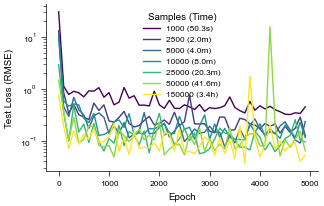

In [242]:
# Prevents matplotlib from converting fonts to paths inside SVG
plt.rcParams['svg.fonttype'] = 'none'

# Height follows golden ratio to maintain clean proportions
fig, ax = plt.subplots(figsize=(single_col, single_col * golden_ratio))

# Convert to Python list because matplotlib colormaps expect native floats
color_indices = torch.linspace(0, 1, len(dataset_sizes)).tolist()
colors = [plt.cm.viridis(val) for val in color_indices]

# 3. Iterate Over Dataset Sizes
for i, n_samples in enumerate(dataset_sizes):

    # Construct file paths for stored history and training time
    hist_path = os.path.join(output_dir, f"history_{n_samples}.pt")
    time_path = os.path.join(output_dir, f"time_{n_samples}.txt")

    # Skip if training history does not exist
    if not os.path.exists(hist_path):
        continue

    # Load and format training time
    t_str = "N/A"
    if os.path.exists(time_path):
        with open(time_path, 'r') as f:
            total = float(f.read().strip())

        # Convert seconds into readable compact format
        if total > 3600:
            t_str = f"{total/3600:.1f}h"
        elif total > 60:
            t_str = f"{total/60:.1f}m"
        else:
            t_str = f"{total:.1f}s"

    data = torch.load(hist_path, map_location='cpu')

    if data['test']:
        epochs, mse = zip(*data['test'])

        # Convert MSE list to torch Tensor to compute sqrt
        rmse = torch.sqrt(torch.tensor(mse)).tolist()

        # Plot curve
        ax.plot(
            epochs,
            rmse,
            color=colors[i],
            label=f"{n_samples} ({t_str})"
        )

# Strict axis formatting
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Loss (RMSE)')

# Remove top/right spines for cleaner scientific aesthetic
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Compact legend (single-column friendly, no frame)
ax.legend(title="Samples (Time)", frameon=False)

# 7. Save as Editable SVG
save_path = os.path.join(output_dir, "nature_loss_comparison.svg")
plt.savefig(save_path, format="svg")

print(f"Figure saved to: {save_path}")
plt.show()

# Section 4: Neural Inverse Dynamics
In this section we derive equations of motion and solve the inverse dynamics problem numerically; the same problem is then solved with the pre-trained neural network. We then compare numerical and neural solutions.

In [243]:
# Random seed for reproducible results
SEED = 23
torch.manual_seed(SEED)

# Number of simulated trajectories
NUM_TRAJECTORIES = 50

# Path for saving the generated dataset
SAVE_PATH = "double_pendulum_dataset.pt"

# Index of the trajectory to visualize
ID_TRAJ = 1

# Dataset sizes (number of samples)
MODEL_NUMS = dataset_sizes

# Base directory for inverse dynamics results
BASE_PATH = output_dir

# Fixed integration time step (seconds)
FIXED_STEP_SIZE = 1e-4

# Test trajectory duration, s
DURATION = 5

# Number of function evaluations (used for statistical testing)
n_repeats = 10000

First, we derive closed-form expressions for the double-pendulum accelerations using the Gibbs-Appell formulation, largely repeating procedures from one of the previous sections.

In [244]:
# Build compile-ready pure PyTorch dynamics kernels.
# The symbolic derivation above remains useful for exposition, but all numerical
# execution below is now performed by native Torch code only.

print('Building pure PyTorch forward-dynamics kernels...')

def _mass_matrix_torch(q1, q2, m1, m2, l1, l2):
    cos_q2 = torch.cos(q2)
    m11 = l1.square() * (m1 + m2) + 2.0 * l1 * l2 * m2 * cos_q2 + l2.square() * m2
    m12 = l2 * m2 * (l1 * cos_q2 + l2)
    m22 = l2.square() * m2

    row_1 = torch.stack((m11, m12), dim=-1)
    row_2 = torch.stack((m12, m22), dim=-1)
    return torch.stack((row_1, row_2), dim=-2)

def _bias_vector_torch(q1, q2, dq1, dq2, m1, m2, l1, l2):
    del q1, m1
    sin_q2 = torch.sin(q2)
    c1 = -l1 * l2 * m2 * sin_q2 * (2.0 * dq1 * dq2 + dq2.square())
    c2 = l1 * l2 * m2 * sin_q2 * dq1.square()
    return torch.stack((c1, c2), dim=-1)

def _gravity_vector_torch(q1, q2, m1, m2, l1, l2, g):
    q12 = q1 + q2
    sin_q1 = torch.sin(q1)
    sin_q12 = torch.sin(q12)
    g1 = g * (l1 * (m1 + m2) * sin_q1 + l2 * m2 * sin_q12)
    g2 = g * l2 * m2 * sin_q12
    return torch.stack((g1, g2), dim=-1)

def _compute_accelerations_torch(q1, q2, dq1, dq2, m1, m2, l1, l2, g):
    M = _mass_matrix_torch(q1, q2, m1, m2, l1, l2)
    C = _bias_vector_torch(q1, q2, dq1, dq2, m1, m2, l1, l2)
    G = _gravity_vector_torch(q1, q2, m1, m2, l1, l2, g)
    rhs = -(C + G)
    ddq = torch.linalg.solve(M, rhs.unsqueeze(-1)).squeeze(-1)
    return ddq[..., 0], ddq[..., 1]

calc_M_robust = compile_torch_function(_mass_matrix_torch, fullgraph=True)
calc_C_robust = compile_torch_function(_bias_vector_torch, fullgraph=True)
calc_G_robust = compile_torch_function(_gravity_vector_torch, fullgraph=True)
compute_accelerations = compile_torch_function(_compute_accelerations_torch, fullgraph=True)

print('Pure PyTorch forward-dynamics kernels are ready.')


Building pure PyTorch forward-dynamics kernels...
Pure PyTorch forward-dynamics kernels are ready.


Second, we rewrite the double-pendulum equations in first-order form so they can be integrated numerically, returning time derivatives of angles and velocities at each step.

In [245]:
# Numerical ODE solvers require the dynamics to be written
# as a first-order system of the form d/dt [q, dq] = f(q, dq).

@torch.compile(dynamic=False, fullgraph=True, mode=TORCH_COMPILE_MODE)
def derive_double_pendulum_ode(t, state, m1_t, m2_t, l1_t, l2_t, g_t):
    del t
    q1_v, q2_v, dq1_v, dq2_v = state.unbind()
    accel_1, accel_2 = _compute_accelerations_torch(
        q1_v, q2_v, dq1_v, dq2_v, m1_t, m2_t, l1_t, l2_t, g_t
    )
    return torch.stack((dq1_v, dq2_v, accel_1, accel_2))


Third, I define a function that generates double-pendulum trajectories by integrating the system's ODEs, recording angles, velocities, and accelerations at each timestep to serve as ground-truth data for later analyses.

In [246]:
# Generate a single double-pendulum trajectory using fixed-step RK4.
def generate_trajectory(duration=5.0, dt=0.001):
    t_axis = torch.arange(0.0, duration + dt, dt, dtype=TORCH_DTYPE, device=device)

    q_init = torch.empty(2, dtype=TORCH_DTYPE, device=device).uniform_(-torch.pi / 3, torch.pi / 3)
    dq_init = torch.zeros(2, dtype=TORCH_DTYPE, device=device)
    state = torch.cat((q_init, dq_init))

    m1_t = as_f32_tensor(PARAMS['m1'], device=device)
    m2_t = as_f32_tensor(PARAMS['m2'], device=device)
    l1_t = as_f32_tensor(PARAMS['l1'], device=device)
    l2_t = as_f32_tensor(PARAMS['l2'], device=device)
    g_t = as_f32_tensor(9.81, device=device)

    traj = []
    for t in t_axis:
        d_state = derive_double_pendulum_ode(t, state, m1_t, m2_t, l1_t, l2_t, g_t)
        ddq = d_state[2:]
        traj.append(torch.cat((state, ddq)))

        k1 = d_state
        k2 = derive_double_pendulum_ode(t + 0.5 * dt, state + 0.5 * dt * k1, m1_t, m2_t, l1_t, l2_t, g_t)
        k3 = derive_double_pendulum_ode(t + 0.5 * dt, state + 0.5 * dt * k2, m1_t, m2_t, l1_t, l2_t, g_t)
        k4 = derive_double_pendulum_ode(t + dt, state + dt * k3, m1_t, m2_t, l1_t, l2_t, g_t)

        state = state + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    return torch.stack(traj), t_axis


If, instead of RK, you want to use semi-implicit Euler integration, uncommnet the cell below.

In [247]:
# If you want to use implicit Euler and not Runge-Kutta solver for the ODE,
# uncomment this cell


# def generate_trajectory(duration=5.0, dt=0.001):
#     """
#     Simulates the system from t=0 to t=duration using Semi-Implicit Euler.
#     Returns the full dataset: [Position, Velocity, Acceleration] at each step.
#     """

#     # Create the time axis
#     # using arange to match step size exactly
#     t_axis = torch.arange(0.0, duration, dt)

#     # Initial Conditions
#     # q:  Uniform between -pi/2 and +pi/2
#     # dq: Uniform between -5 and +5 rad/s
#     q  = torch.empty(2).uniform_(-torch.pi/2, torch.pi/2)
#     dq = torch.zeros(2)

#     traj = []

#     # Integration Loop (Semi-Implicit Euler)
#     for t in t_axis:

#         # 1. Compute Dynamics (Acceleration)
#         # We temporarily pack state for the physics function
#         state_for_calc = torch.cat([q, dq])

#         d_state = derive_double_pendulum_ode(t, state_for_calc, PARAMS)
#         ddq = d_state[2:] # Extract acceleration

#         # 2. Store Snapshot: [q, dq, ddq]
#         # We store the state *before* the update to align input (q, dq) with target (ddq)
#         traj.append(torch.cat([q, dq, ddq]))

#         # 3. Semi-Implicit Euler Step
#         # Update Velocity FIRST
#         dq = dq + ddq * dt

#         # Update Position SECOND (using the new velocity)
#         q = q + dq * dt

#     # Stack the list of snapshots into a single Tensor [TimeSteps, 6]
#     return torch.stack(traj), t_axis

Next, we define a function that uses a trained neural network to compute generalized forces by differentiating the learned Gibbs-Appell function with respect to accelerations.

In [248]:
def get_neural_torques(model, state_vector_norm, y_std, x_std):
    state_input = state_vector_norm.detach().clone().requires_grad_(True)
    s_pred_norm = model(state_input)
    grads = autograd.grad(
        outputs=s_pred_norm.sum(),
        inputs=state_input,
        create_graph=False,
    )[0]

    scale_factor = y_std / (x_std[4:6] + TORCH_EPS)
    return grads[:, 4:6] * scale_factor


Subsequently, we create a fixed test set to evaluate all networks consistently, either by loading a cached (previously generated and stored in file) dataset or generating new trajectories.

In [249]:
# Setup file path for the fixed test set
TEST_SET_FILENAME = f"test_set_{NUM_TRAJECTORIES}_traj_{DURATION}s.pt"
test_set_path = os.path.join(BASE_PATH, TEST_SET_FILENAME)

m1_t = as_f32_tensor(PARAMS['m1'], device=device)
m2_t = as_f32_tensor(PARAMS['m2'], device=device)
l1_t = as_f32_tensor(PARAMS['l1'], device=device)
l2_t = as_f32_tensor(PARAMS['l2'], device=device)

if os.path.exists(test_set_path):
    print(f"Found cached test set at: {test_set_path}")
    print('Loading test set from file...')

    cached_data = torch.load(test_set_path, map_location='cpu')
    FIXED_INPUTS = cached_data['inputs']
    FIXED_TARGETS = cached_data['targets']
    fixed_time_axis = cached_data['time_axis']

    print(f"Loaded successfully. Shape: {FIXED_INPUTS.shape}")
else:
    print(f"Cache not found. Generating fixed test set with {NUM_TRAJECTORIES} trajectories...")

    fixed_inputs_list = []
    fixed_targets_list = []
    fixed_time_axis = None

    for i in range(NUM_TRAJECTORIES):
        print(f"Generating Trajectory {i + 1}/{NUM_TRAJECTORIES}")

        traj_data, time_axis = generate_trajectory(duration=DURATION, dt=FIXED_STEP_SIZE)

        if fixed_time_axis is None:
            fixed_time_axis = time_axis.cpu()

        traj_data = traj_data.to(device=device, dtype=TORCH_DTYPE)
        tau1_true, tau2_true = compute_tau_ground_truth(
            traj_data[:, 0], traj_data[:, 1],
            traj_data[:, 2], traj_data[:, 3],
            traj_data[:, 4], traj_data[:, 5],
            m1_t, m2_t, l1_t, l2_t,
        )
        traj_true = torch.stack((tau1_true, tau2_true), dim=1)

        fixed_inputs_list.append(traj_data.cpu())
        fixed_targets_list.append(traj_true.cpu())

    FIXED_INPUTS = torch.stack(fixed_inputs_list)
    FIXED_TARGETS = torch.stack(fixed_targets_list)

    print(f"Saving generated test set to: {test_set_path}")
    torch.save({
        'inputs': FIXED_INPUTS,
        'targets': FIXED_TARGETS,
        'time_axis': fixed_time_axis,
    }, test_set_path)

    if IN_COLAB:
        files.download(test_set_path)

    print(f"Test set ready. Shape: {FIXED_INPUTS.shape}")


Found cached test set at: ./test_set_50_traj_5s.pt
Loading test set from file...
Loaded successfully. Shape: torch.Size([50, 50001, 6])


Following that, we evaluate each trained model on the fixed test set by predicting torques, timing inference, and computing RMSE for both joints.

In [250]:
# Instantiate the network once for evaluation
model = GibbsAppellNet().to(device)

# We only need gradients with respect to the inputs during torque inference.
for param in model.parameters():
    param.requires_grad_(False)

fixed_inputs_device = FIXED_INPUTS.to(device=device, dtype=torch.float32)
fixed_targets_device = FIXED_TARGETS.to(device=device, dtype=torch.float32)
perf_counter = time.perf_counter

# Evaluation loop for models trained on different dataset sizes
for num in MODEL_NUMS:
    print(f"\n{'='*40}")
    print(f"Processing Model: {num} samples")
    print(f"{'='*40}")

    model_path = os.path.join(BASE_PATH, f"model_{num}.pth")
    stats_path = os.path.join(BASE_PATH, f"stats_{num}.pt")
    save_name  = f"results_model_{num}.pt"
    full_save_path = os.path.join(BASE_PATH, save_name)

    # Skip if results already exist
    if os.path.exists(full_save_path):
        print(f"Skipping Model {num}: Results already exist ({save_name})")
        continue

    # Load normalization statistics once and precompute reusable scale factors.
    model_stats = torch.load(stats_path, map_location=device)
    stats_mean  = model_stats['X_mean'].to(device=device, dtype=torch.float32)
    stats_X_std = model_stats['X_std'].to(device=device, dtype=torch.float32)
    stats_S_std = model_stats['S_std'].to(device=device, dtype=torch.float32)
    inv_X_std   = 1.0 / (stats_X_std + 1e-8)
    torque_scale = stats_S_std / (stats_X_std[4:6] + 1e-8)

    # Load trained weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Preallocate outputs to avoid repeated Python list growth in the hot loop.
    all_pred_tau = torch.empty_like(fixed_targets_device)
    inference_times = torch.empty(NUM_TRAJECTORIES, dtype=torch.float64)

    # Loop over fixed test trajectories
    for i in range(NUM_TRAJECTORIES):
        if (i + 1) % 10 == 0:
            print(f"Evaluating Trajectory {i + 1}/{NUM_TRAJECTORIES}")

        # Normalize once, then take gradients directly with respect to the input.
        input_norm = (fixed_inputs_device[i] - stats_mean) * inv_X_std
        input_norm.requires_grad_(True)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        t_start = perf_counter()

        s_pred_norm = model(input_norm)
        grads = autograd.grad(
            outputs=s_pred_norm.sum(),
            inputs=input_norm,
            create_graph=False
        )[0]
        t_pred = grads[:, 4:6] * torque_scale

        if device.type == 'cuda':
            torch.cuda.synchronize()
        inference_times[i] = perf_counter() - t_start

        all_pred_tau[i].copy_(t_pred.detach())

    # Compute RMSE after the loop in one vectorized pass.
    rmse = torch.sqrt(torch.mean((fixed_targets_device - all_pred_tau) ** 2, dim=1))
    rmse_j1_list = rmse[:, 0].cpu().tolist()
    rmse_j2_list = rmse[:, 1].cpu().tolist()

    # Save results for this model
    print(f"Saving results for model_{num}...")

    model_results = {
        str(FIXED_STEP_SIZE): {
            "inputs":        FIXED_INPUTS,
            "torques_true":  FIXED_TARGETS,
            "torques_pred":  all_pred_tau.cpu(),
            "time_axis":     fixed_time_axis,
            "rmse_j1":       rmse_j1_list,
            "rmse_j2":       rmse_j2_list,
            "inference_times": inference_times.tolist(),
            "dt":            FIXED_STEP_SIZE
        }
    }
    torch.save(model_results, full_save_path)

print("\nAll models processed on the same trajectories.")



Processing Model: 1000 samples
Skipping Model 1000: Results already exist (results_model_1000.pt)

Processing Model: 2500 samples
Skipping Model 2500: Results already exist (results_model_2500.pt)

Processing Model: 5000 samples
Skipping Model 5000: Results already exist (results_model_5000.pt)

Processing Model: 10000 samples
Skipping Model 10000: Results already exist (results_model_10000.pt)

Processing Model: 25000 samples
Skipping Model 25000: Results already exist (results_model_25000.pt)

Processing Model: 50000 samples
Skipping Model 50000: Results already exist (results_model_50000.pt)

Processing Model: 150000 samples
Skipping Model 150000: Results already exist (results_model_150000.pt)

All models processed on the same trajectories.


Afterward, we benchmark the inference timing of models trained on different dataset sizes using repeated interleaved evaluation.

In [251]:
# Output file for benchmark results
save_path = os.path.join(output_dir, "timing_benchmark_interleaved.pt")

# Flag to decide whether to run the benchmark
run_simulation = True

# Check if benchmark file exists and is valid
if os.path.exists(save_path):
    print(f"Found existing benchmark file at: {save_path}")
    try:
        checkpoint = torch.load(save_path)
        temp_data = checkpoint['benchmark_data']

        # Only use if data is already in dictionary format
        if isinstance(temp_data, dict):
            final_data = temp_data
            sizes_to_test = checkpoint['sizes_to_test']
            print("Data in correct format. Loading complete.")
            run_simulation = False
        else:
            print("WARNING: Old format detected. Re-running simulation...")
    except Exception as e:
        print(f"Error reading file ({e}). Re-running...")
else:
    print("No existing benchmark found. Starting new simulation...")

# Run benchmark if needed
if run_simulation:
    sizes_to_test = dataset_sizes
    benchmark_data = {size: [] for size in sizes_to_test}

    # Fix random seeds for reproducibility
    print(f"Setting random seed: {SEED}")
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Prepare dummy input for timing evaluation
    dummy_input = torch.rand(1, 6, dtype=TORCH_DTYPE, device=device)
    dummy_input.requires_grad_(True)

    # Load all model weights and normalization stats into memory
    print("Loading models and stats...")
    model_pool = {}
    stats_pool = {}
    for size in sizes_to_test:
        model_pool[size] = torch.load(os.path.join(BASE_PATH, f"model_{size}.pth"), map_location=device)
        loaded_stats = torch.load(os.path.join(BASE_PATH, f"stats_{size}.pt"), map_location=device)
        stats_pool[size] = {'S_std': loaded_stats['S_std'].to(device),
                            'X_std': loaded_stats['X_std'].to(device)}

    # Instantiate network structure
    model = GibbsAppellNet().to(device)

    print(f"Running interleaved benchmark on {device}...")

    # Repeat timing measurements
    for i in range(n_repeats):
        if (i+1) % 500 == 0:
            print(f"Batch {i+1}/{n_repeats}")

        # Random order of dataset sizes each iteration
        indices = torch.randperm(len(sizes_to_test))
        for idx in indices:
            size = sizes_to_test[idx]

            # Load weights and set model to evaluation
            model.load_state_dict(model_pool[size])
            model.eval()

            stats_S_std = stats_pool[size]['S_std']
            stats_X_std = stats_pool[size]['X_std']

            # Measure inference time
            if device.type == 'cuda': torch.cuda.synchronize()
            t_start = time.perf_counter()
            _ = get_neural_torques(model, dummy_input, stats_S_std, stats_X_std)
            if device.type == 'cuda': torch.cuda.synchronize()
            t_end = time.perf_counter()

            benchmark_data[size].append((t_end - t_start) * 1000.0)  # ms

    # Convert timing lists to tensors
    final_data = {size: torch.tensor(benchmark_data[size], dtype=TORCH_DTYPE) for size in sizes_to_test}

    # Save benchmark results
    print(f"Saving benchmark results to: {save_path}")
    torch.save({'benchmark_data': final_data, 'sizes_to_test': sizes_to_test}, save_path)

    print("Benchmarking complete.")


Found existing benchmark file at: ./timing_benchmark_interleaved.pt
Data in correct format. Loading complete.


### Measuring inference time

Next, we load or generate forward passes of the models with a dummy input to  measure inference time for each dataset size.

In [252]:
# Check for existing data
run_simulation = True
if os.path.exists(save_path):
    print(f"Found existing benchmark file at: {save_path}")
    try:
        checkpoint = torch.load(save_path)
        temp_data = checkpoint['benchmark_data']

        # Validate that data is a dictionary
        if isinstance(temp_data, dict):
            final_data = temp_data
            sizes_to_test = checkpoint['sizes_to_test']
            print("Data is in correct format. Loading complete.")
            run_simulation = False
        else:
            print("Warning: existing data is in old format (list). Discarding and re-running...")
    except Exception as e:
        print(f"Error reading existing file ({e}). Re-running...")
else:
    print("No existing benchmark found. Starting new simulation...")

# Run simulation if needed
if run_simulation:
    sizes_to_test = dataset_sizes
    benchmark_data = {size: [] for size in sizes_to_test}

    # Set random seeds
    print(f"Setting random seed to: {SEED}")
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Create dummy input for benchmarking
    dummy_input = torch.rand(1, 6, dtype=TORCH_DTYPE, device=device)
    dummy_input.requires_grad_(True)

    # Pre-load model weights and statistics
    print("Pre-loading models and stats into memory...")
    model_pool = {}
    stats_pool = {}

    for size in sizes_to_test:
        # Load model weights
        path_model = os.path.join(BASE_PATH, f"model_{size}.pth")
        model_pool[size] = torch.load(path_model, map_location=device)

        # Load normalization statistics
        path_stats = os.path.join(BASE_PATH, f"stats_{size}.pt")
        loaded_stats = torch.load(path_stats, map_location=device)

        stats_pool[size] = {
            'S_std': loaded_stats['S_std'].to(device),
            'X_std': loaded_stats['X_std'].to(device)
        }

    # Instantiate model once
    model = GibbsAppellNet().to(device)

    print(f"Starting interleaved benchmark on device: {device}...")

    for i in range(n_repeats):
        if (i + 1) % 500 == 0:
            print(f"Batch {i + 1}/{n_repeats}...")

        # Shuffle sizes to avoid ordering bias
        indices = torch.randperm(len(sizes_to_test))

        for idx in indices:
            size = sizes_to_test[idx]

            # Hot-swap model weights
            model.load_state_dict(model_pool[size])
            model.eval()

            # Select stats for this size
            stats_S_std = stats_pool[size]['S_std']
            stats_X_std = stats_pool[size]['X_std']

            # Measure inference time
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t_start = time.perf_counter()

            # Forward pass through model
            _ = get_neural_torques(model, dummy_input, stats_S_std, stats_X_std)

            if device.type == 'cuda':
                torch.cuda.synchronize()
            t_end = time.perf_counter()

            benchmark_data[size].append((t_end - t_start) * 1000.0)

    # Convert benchmark data to tensors
    final_data = {size: torch.tensor(benchmark_data[size], dtype=TORCH_DTYPE) for size in sizes_to_test}

    # Save benchmark results
    print(f"Saving new benchmark results to: {save_path}")
    torch.save({
        'benchmark_data': final_data,
        'sizes_to_test': sizes_to_test
    }, save_path)

    print("Benchmarking complete.")


Found existing benchmark file at: ./timing_benchmark_interleaved.pt
Data is in correct format. Loading complete.


Following this, we perform statistical analysis.

In [253]:
import scipy.stats as scipy_stats

# Prepare a dataframe
data_records = []
for size, timings in final_data.items():
    timing_values = timings.to(dtype=TORCH_DTYPE).cpu().tolist()
    for value in timing_values:
        data_records.append({'Dataset_Size': str(size), 'Time_ms': value})

df = pd.DataFrame(data_records)

print("\n" + '=' * 50)
print('Statistical analysis')
print('=' * 50)

print(f"\n{'Dataset Size':<15} | {'Shapiro-Wilk p-value':<20} | {'Result'}")
print('-' * 55)

is_normal = True
grouped_data = []
sorted_sizes = sorted(sizes_to_test)

for size in sorted_sizes:
    times = df[df['Dataset_Size'] == str(size)]['Time_ms']
    grouped_data.append(times)

    stat, p_value = scipy_stats.shapiro(times)
    is_distribution_normal = p_value > 0.05
    if not is_distribution_normal:
        is_normal = False

    res_str = 'Normal' if is_distribution_normal else 'Not normal'
    print(f"{str(size):<15} | {p_value:.4e}{' ' * 10} | {res_str}")

print('\n--- Hypothesis testing ---')
if is_normal:
    stat, p_val = scipy_stats.f_oneway(*grouped_data)
    test_name = 'One-way ANOVA'
else:
    stat, p_val = scipy_stats.kruskal(*grouped_data)
    test_name = 'Kruskal-Wallis H-test'

print(f"Test performed: {test_name}")
print(f"Statistic: {stat:.4f} | P-Value: {p_val:.4e}")

if p_val < 0.05:
    print('>> Result: Significant difference detected (reject H0).')
else:
    print('>> Result: No significant difference (fail to reject H0).')

print('\n--- Descriptive statistics ---')
print(f"{'Dataset Size':<15} | {'N':<6} | {'Mean +/- Std (ms)':<20} | {'Median [IQR] (ms)':<20} | {'Min / Max'}")
print('-' * 95)

for size in sorted_sizes:
    group_data = df[df['Dataset_Size'] == str(size)]['Time_ms']

    n = len(group_data)
    mean = group_data.mean()
    std = group_data.std()
    q1 = group_data.quantile(0.25)
    median = group_data.median()
    q3 = group_data.quantile(0.75)
    iqr = q3 - q1
    min_val = group_data.min()
    max_val = group_data.max()

    mean_std_str = f"{mean:.3f} +/- {std:.3f}"
    median_iqr_str = f"{median:.3f} [{iqr:.3f}]"
    min_max_str = f"{min_val:.3f} / {max_val:.3f}"

    print(f"{str(size):<15} | {n:<6} | {mean_std_str:<20} | {median_iqr_str:<20} | {min_max_str}")

print('-' * 95)

all_times = df['Time_ms']
global_mean = all_times.mean()
global_std = all_times.std()
global_median = all_times.median()

print('Overall (all sizes combined):')
print(f"Mean +/- Std:    {global_mean:.4f} +/- {global_std:.4f} ms")
print(f"Median:          {global_median:.4f} ms")
print('-' * 95 + '\n')



Statistical analysis

Dataset Size    | Shapiro-Wilk p-value | Result
-------------------------------------------------------
1000            | 4.5234e-112           | Not normal
2500            | 1.3390e-109           | Not normal
5000            | 9.3807e-110           | Not normal
10000           | 3.5460e-114           | Not normal
25000           | 1.9302e-108           | Not normal
50000           | 5.8547e-112           | Not normal

--- Hypothesis testing ---
Test performed: Kruskal-Wallis H-test
Statistic: 11.2359 | P-Value: 4.6898e-02
>> Result: Significant difference detected (reject H0).

--- Descriptive statistics ---
Dataset Size    | N      | Mean +/- Std (ms)    | Median [IQR] (ms)    | Min / Max
-----------------------------------------------------------------------------------------------
1000            | 10000  | 0.077 +/- 0.016      | 0.076 [0.003]        | 0.068 / 1.009
2500            | 10000  | 0.077 +/- 0.011      | 0.076 [0.003]        | 0.068 / 0.547
5000   

/opt/anaconda3/envs/gibbs-apell-env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


Finally, we generate a figure of inference speed across dataset sizes using Nature style settings.


Nature Communications style applied.
Saving figure to: ./nature_inference_speed_benchmark.svg


/var/folders/cx/l78s05fd0g396nwgtwhlw7n40000gn/T/ipykernel_5302/1178526206.py:18: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(


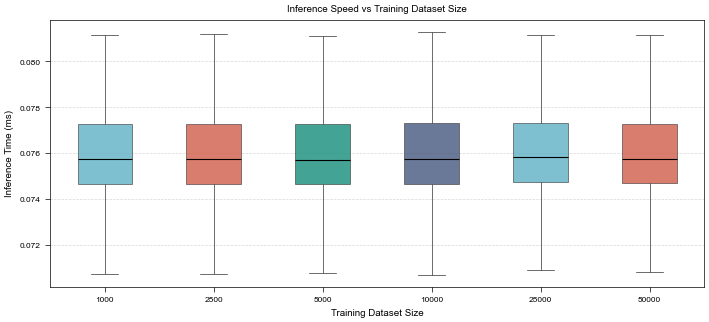

In [254]:
save_path        = os.path.join(output_dir, "timing_benchmark_interleaved.pt")
figure_save_path = os.path.join(output_dir, "nature_inference_speed_benchmark.svg")

# Apply the settings globally
single_col, double_col, golden_ratio = set_nature_style()
print("Nature Communications style applied.")

# Use double column width for the plot
fig_width  = double_col
fig_height = double_col * golden_ratio * 0.75  # Adjust height slightly for better aspect ratio in paper

plt.figure(figsize=(fig_width, fig_height))

# Enable y-axis grid with subtle lines (optional in Nature)
plt.grid(True, axis='y', linestyle='--', alpha=0.5, linewidth=0.5)

# Create boxplot using seaborn
ax = sns.boxplot(
    x='Dataset_Size',
    y='Time_ms',
    hue='Dataset_Size',
    data=df,
    order=[str(s) for s in sorted_sizes],
    palette=['#4DBBD5', '#E64B35', '#00A087', '#3C5488'],
    showfliers=False,
    width=0.5,
    boxprops=dict(alpha=0.8, linewidth=0.5),
    whiskerprops=dict(linewidth=0.5),
    capprops=dict(linewidth=0.5),
    medianprops=dict(linewidth=0.8, color='black'),
    legend=False
)

# Set axis labels and title
plt.title('Inference Speed vs Training Dataset Size')
plt.ylabel('Inference Time (ms)')
plt.xlabel('Training Dataset Size')

# Adjust layout for better fit
plt.tight_layout()

# Save figure as high-resolution PDF
print(f"Saving figure to: {figure_save_path}")
plt.savefig(figure_save_path, dpi=600)  # Explicit dpi for publication quality

# Display the figure
plt.show()


### Measuring prediction accuracy

First, we load RMSE results from saved model outputs and organize them into a DataFrame.


In [255]:
# Configuration
results_path  = BASE_PATH
sorted_sizes  = sorted(MODEL_NUMS)  # Ensure dataset sizes are processed in ascending order

print(f"Loading RMSE results from: {results_path}")
records = []

for size in sorted_sizes:
    filename  = f"results_model_{size}.pt"
    full_path = os.path.join(results_path, filename)

    # Skip if file does not exist
    if not os.path.exists(full_path):
        print(f"Warning: {filename} not found.")
        continue

    # Load the saved results
    data = torch.load(full_path)

    # Extract the inner dict (grab the first available key, e.g., step size)
    key = list(data.keys())[0]
    res = data[key]

    # Unpack RMSE lists for each joint
    rmse_j1 = res['rmse_j1']
    rmse_j2 = res['rmse_j2']

    # Append each value to records for the DataFrame
    for val in rmse_j1:
        records.append({'Dataset_Size': size, 'Joint': 'J1', 'RMSE': val})
    for val in rmse_j2:
        records.append({'Dataset_Size': size, 'Joint': 'J2', 'RMSE': val})

# Create a pandas DataFrame from all records
df_rmse = pd.DataFrame(records)
print(f"Data loaded. DataFrame shape: {df_rmse.shape}")


Loading RMSE results from: .
Data loaded. DataFrame shape: (700, 3)


Second, we perform a Shapiro-Wilk normality test on RMSE values for each joint and dataset size

In [256]:
import scipy.stats as scipy_stats

print(f"\n{'='*20} Normality Test (Shapiro-Wilk) {'='*20}")
print(f"{'Joint':<6} | {'Dataset Size':<12} | {'P-Value':<12} | {'Distribution'}")
print("-" * 60)

# Dictionary to store normality results
normality_results = {}

for joint in ['J1', 'J2']:
    for size in sorted_sizes:

        # Extract RMSE values for this joint and dataset size
        subset = df_rmse[(df_rmse['Dataset_Size'] == size) & (df_rmse['Joint'] == joint)]['RMSE']

        # Perform Shapiro-Wilk test
        stat, p = scipy_stats.shapiro(subset)
        is_normal = p > 0.05
        normality_results[(joint, size)] = is_normal

        # Prepare distribution label
        dist_str = "Normal" if is_normal else "Not Normal"

        # Highlight significant deviations with asterisk
        p_str = f"{p:.2e}"
        if not is_normal:
            p_str = f"*{p_str}"

        # Print results in a table-like format
        print(f"{joint:<6} | {str(size):<12} | {p_str:<12} | {dist_str}")

print("-" * 60)
print("* p < 0.05 indicates data is not normally distributed.")


==================== Normality Test (Shapiro-Wilk) ====================
Joint  | Dataset Size | P-Value      | Distribution
------------------------------------------------------------
J1     | 1000         | *1.78e-02    | Not Normal
J1     | 2500         | *1.82e-03    | Not Normal
J1     | 5000         | *3.33e-06    | Not Normal
J1     | 10000        | *3.22e-11    | Not Normal
J1     | 25000        | *3.29e-06    | Not Normal
J1     | 50000        | *5.40e-15    | Not Normal
J1     | 150000       | *3.28e-10    | Not Normal
J2     | 1000         | *1.93e-06    | Not Normal
J2     | 2500         | *1.17e-10    | Not Normal
J2     | 5000         | *3.89e-09    | Not Normal
J2     | 10000        | *4.64e-13    | Not Normal
J2     | 25000        | *1.86e-10    | Not Normal
J2     | 50000        | *4.90e-15    | Not Normal
J2     | 150000       | *1.08e-13    | Not Normal
------------------------------------------------------------
* p < 0.05 indicates data is not normally distributed

Third, we calculate and plot pairwise significance matrices (p-values) for RMSE comparisons across dataset sizes.



==================== Pairwise Statistical Matrices ====================


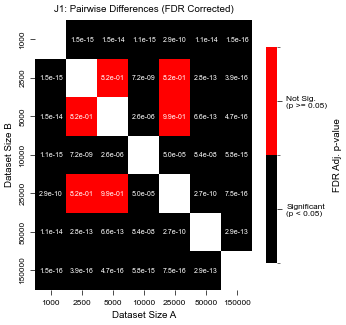


--- Statistical Summary for Joint J1 ---
To assess the impact of dataset size on model performance for joint J1, pairwise Mann-Whitney U tests were performed on the RMSE distributions.
To control the false discovery rate associated with multiple comparisons (21 tests), p-values were adjusted using the Benjamini-Hochberg procedure with a significance threshold of alpha = 0.05.
Statistically significant differences in RMSE (FDR-adjusted p < 0.05) were found for the following comparisons: 1000 vs 2500, 1000 vs 5000, 1000 vs 10000, 1000 vs 25000, 1000 vs 50000, 1000 vs 150000, 2500 vs 10000, 2500 vs 50000, 2500 vs 150000, 5000 vs 10000, 5000 vs 50000, 5000 vs 150000, 10000 vs 25000, 10000 vs 50000, 10000 vs 150000, 25000 vs 50000, 25000 vs 150000, 50000 vs 150000.
However, no significant differences were observed between: 2500 vs 5000, 2500 vs 25000, 5000 vs 25000.
--------------------------------------------------



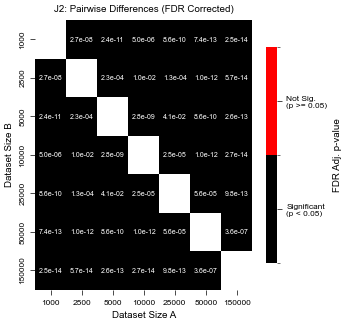


--- Statistical Summary for Joint J2 ---
To assess the impact of dataset size on model performance for joint J2, pairwise Mann-Whitney U tests were performed on the RMSE distributions.
To control the false discovery rate associated with multiple comparisons (21 tests), p-values were adjusted using the Benjamini-Hochberg procedure with a significance threshold of alpha = 0.05.
The analysis revealed that all pairwise comparisons between different dataset sizes yielded statistically significant differences in RMSE (FDR-adjusted p < 0.05). This indicates that every tested increase in dataset size resulted in a measurable change in model performance.
--------------------------------------------------



In [257]:
import scipy.stats as scipy_stats

def plot_significance_matrix(joint_name, df, sizes, save_path=None, correction='fdr_bh'):
    n = len(sizes)
    p_matrix = torch.full((n, n), float('nan'), dtype=TORCH_DTYPE)

    raw_p_values = []
    indices = []
    for i in range(n):
        for j in range(i + 1, n):
            size_a = sizes[i]
            size_b = sizes[j]

            data_a = df[(df['Dataset_Size'] == size_a) & (df['Joint'] == joint_name)]['RMSE']
            data_b = df[(df['Dataset_Size'] == size_b) & (df['Joint'] == joint_name)]['RMSE']

            _, p = scipy_stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
            raw_p_values.append(p)
            indices.append((i, j))

    reject, corrected_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method=correction)

    for k, (i, j) in enumerate(indices):
        corrected_p = float(corrected_p_values[k])
        p_matrix[i, j] = corrected_p
        p_matrix[j, i] = corrected_p

    fig_width = single_col
    plt.figure(figsize=(fig_width, fig_width))

    mask = torch.eye(n, dtype=torch.bool)
    p_matrix_df = pd.DataFrame(p_matrix.cpu().tolist(), index=sizes, columns=sizes)
    mask_df = pd.DataFrame(mask.cpu().tolist(), index=sizes, columns=sizes)

    cmap = mcolors.ListedColormap(['black', 'red'])
    bounds = [0.0, 0.05, 1.0]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    ax = sns.heatmap(
        p_matrix_df,
        annot=True,
        fmt='.1e',
        mask=mask_df,
        xticklabels=sizes,
        yticklabels=sizes,
        cmap=cmap,
        norm=norm,
        cbar_kws={'label': 'FDR Adj. p-value', 'shrink': 0.8, 'ticks': [0.025, 0.525]},
        annot_kws={'size': 5},
    )

    colorbar = ax.collections[0].colorbar
    colorbar.set_ticklabels(['Significant\n(p < 0.05)', 'Not Sig.\n(p >= 0.05)'])

    plt.title(f'{joint_name}: Pairwise Differences (FDR Corrected)')
    plt.xlabel('Dataset Size A')
    plt.ylabel('Dataset Size B')

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')

    plt.show()

    print(f"\n--- Statistical Summary for Joint {joint_name} ---")
    print(
        f"To assess the impact of dataset size on model performance for joint {joint_name}, "
        f"pairwise Mann-Whitney U tests were performed on the RMSE distributions."
    )
    print(
        f"To control the false discovery rate associated with multiple comparisons ({len(raw_p_values)} tests), "
        f"p-values were adjusted using the Benjamini-Hochberg procedure with a significance threshold of alpha = 0.05."
    )

    sig_pairs = []
    nonsig_pairs = []
    for k, (i, j) in enumerate(indices):
        pair_str = f"{sizes[i]} vs {sizes[j]}"
        if reject[k]:
            sig_pairs.append(pair_str)
        else:
            nonsig_pairs.append(pair_str)

    if len(nonsig_pairs) == 0:
        print(
            'The analysis revealed that all pairwise comparisons between different dataset sizes '
            'yielded statistically significant differences in RMSE (FDR-adjusted p < 0.05). '
            'This indicates that every tested increase in dataset size resulted in a measurable '
            'change in model performance.'
        )
    elif len(sig_pairs) == 0:
        print(
            'The analysis revealed no statistically significant differences in RMSE between any of '
            'the dataset sizes (FDR-adjusted p >= 0.05).'
        )
    else:
        print(
            f"Statistically significant differences in RMSE (FDR-adjusted p < 0.05) were found for "
            f"the following comparisons: {', '.join(sig_pairs)}."
        )
        print(f"However, no significant differences were observed between: {', '.join(nonsig_pairs)}.")
    print('-' * 50 + '\n')

print(f"\n{'=' * 20} Pairwise Statistical Matrices {'=' * 20}")

path_j1 = os.path.join(results_path, 'significance_matrix_j1.pdf')
plot_significance_matrix('J1', df_rmse, sorted_sizes, save_path=path_j1)

path_j2 = os.path.join(results_path, 'significance_matrix_j2.pdf')
plot_significance_matrix('J2', df_rmse, sorted_sizes, save_path=path_j2)


Lastly, we create box plots to visualize RMSE distribution across dataset sizes for each joint.


==================== Descriptive Statistics (RMSE) ====================
Joint  | Dataset Size | Mean ± Std           | Median [IQR]        
----------------------------------------------------------------------
J1     | 1000         | 0.1462 ± 0.0495      | 0.1327 [0.0577]     
J1     | 2500         | 0.0585 ± 0.0187      | 0.0527 [0.0272]     
J1     | 5000         | 0.0593 ± 0.0249      | 0.0567 [0.0284]     
J1     | 10000        | 0.0423 ± 0.0223      | 0.0377 [0.0089]     
J1     | 25000        | 0.0710 ± 0.0468      | 0.0514 [0.0576]     
J1     | 50000        | 0.1720 ± 0.7429      | 0.0289 [0.0063]     
J1     | 150000       | 0.0140 ± 0.0080      | 0.0117 [0.0041]     
J2     | 1000         | 0.0800 ± 0.0417      | 0.0712 [0.0475]     
J2     | 2500         | 0.0482 ± 0.0220      | 0.0406 [0.0125]     
J2     | 5000         | 0.0372 ± 0.0234      | 0.0337 [0.0194]     
J2     | 10000        | 0.0533 ± 0.0310      | 0.0464 [0.0039]     
J2     | 25000        | 0.0387 ± 0.0429 

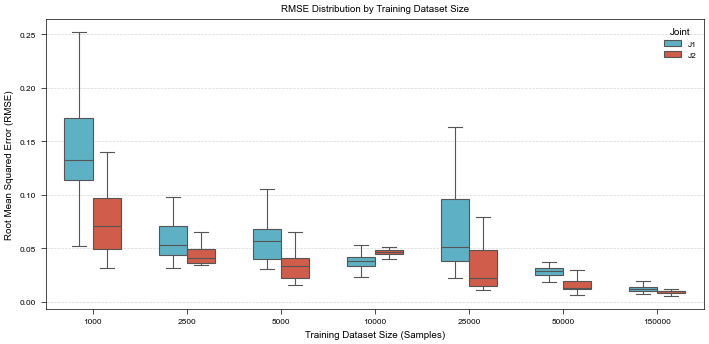

In [258]:
# Calculate and print descriptive statistics for RMSE
print(f"\n{'='*20} Descriptive Statistics (RMSE) {'='*20}")
print(f"{'Joint':<6} | {'Dataset Size':<12} | {'Mean ± Std':<20} | {'Median [IQR]':<20}")
print("-" * 70)

# Ensure sorting for consistent output
joints = sorted(df_rmse['Joint'].unique())
sizes  = sorted(df_rmse['Dataset_Size'].unique(), key=int)

# Following this, we loop through each joint and dataset size to compute descriptive metrics
for joint in joints:
    for size in sizes:
        # Filter the data for the current joint and dataset size
        subset = df_rmse[(df_rmse['Dataset_Size'] == size) & (df_rmse['Joint'] == joint)]['RMSE']
        if len(subset) == 0:
            continue

        # Compute mean, standard deviation, median, and interquartile range
        mean_val = subset.mean()
        std_val  = subset.std()
        median   = subset.median()
        q1       = subset.quantile(0.25)
        q3       = subset.quantile(0.75)
        iqr      = q3 - q1

        # Format metrics for clean printing
        mean_std = f"{mean_val:.4f} ± {std_val:.4f}"
        med_iqr  = f"{median:.4f} [{iqr:.4f}]"

        print(f"{joint:<6} | {str(size):<12} | {mean_std:<20} | {med_iqr:<20}")

print("-" * 70 + "\n")


# Generate and save box plot for RMSE distribution

# Following this, we create a Nature-style box plot for RMSE across dataset sizes

# Define file path for saving figure
fig_name = "nature_rmse_distribution_boxplot.svg"
save_fig_path = os.path.join(results_path, fig_name)

# Set figure dimensions for double-column width (Nature style)
fig_width  = double_col
fig_height = double_col * golden_ratio * 0.8  # Slightly shorter for compactness
plt.figure(figsize=(fig_width, fig_height))

# Create box plot with joint-specific colors and no outliers
ax = sns.boxplot(
    data=df_rmse,
    x='Dataset_Size',
    y='RMSE',
    hue='Joint',
    palette=['#4DBBD5', '#E64B35'],  # Nature-style blue/red
    showfliers=False,                 # Hide outliers for cleaner view
    width=0.6,
    linewidth=0.8
)

# Set plot title and axis labels
plt.title('RMSE Distribution by Training Dataset Size')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xlabel('Training Dataset Size (Samples)')

# Configure legend without frame
plt.legend(title='Joint', loc='upper right', frameon=False)

# Add light horizontal grid lines for clarity
plt.grid(True, axis='y', linestyle='--', alpha=0.5, linewidth=0.5)

# Adjust layout, save figure at high resolution, and display
plt.tight_layout()
plt.savefig(save_fig_path, dpi=600)
print(f"Figure saved to: {save_fig_path}")

plt.show()


### Supplementary

As a cherry on the top, here, we load saved model predictions for a fixed test trajectory and compare predicted joint torques across training dataset sizes against the same ground truth over time.

Loading data for trial #0...
Loaded: N=1,000
Skipping results_model_15000.pt, file not found.
Plotting results with Nature style...
Figures saved as nature_torque_trajectory_comparison.pdf and nature_torque_trajectory_comparison.png


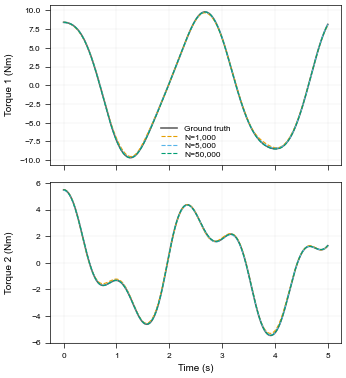

In [259]:
# Configuration
MODEL_FOLDER = BASE_PATH
RESULT_FILES = [
    'results_model_1000.pt',
    'results_model_5000.pt',
    'results_model_15000.pt',
    'results_model_50000.pt'
]
STEP_SIZE_KEY = "0.0001"
TRIAL_IDX     = 0

colors      = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
line_styles = ['--', '--', '--', '--']

# Initialize containers
ground_truth      = None
time_axis         = None
model_predictions = {}

print(f"Loading data for trial #{TRIAL_IDX}...")

# Load prediction and ground-truth data for each trained model
for i, res_file in enumerate(RESULT_FILES):
    load_path = os.path.join(MODEL_FOLDER, res_file)

    if not os.path.exists(load_path):
        print(f"Skipping {res_file}, file not found.")
        continue

    try:
        checkpoint = torch.load(load_path, map_location='cpu')

        # Extract results for the selected integration step size
        if 'results_by_step_size' in checkpoint:
            data = checkpoint['results_by_step_size'][STEP_SIZE_KEY]
        else:
            data = checkpoint[STEP_SIZE_KEY]

        # Create a clean label from the dataset size
        raw_num = res_file.replace('results_model_', '').replace('.pt', '').replace('.pth', '')
        label   = f"N={int(raw_num):,}"

        # Extract predictions, ground truth, and time axis
        curr_pred = data['torques_pred'][TRIAL_IDX]
        curr_true = data['torques_true'][TRIAL_IDX]
        curr_time = data['time_axis']

        # Sanity check consistency of ground truth across models
        if ground_truth is not None:
            if not torch.allclose(curr_true, ground_truth, atol=1e-4):
                print(f"Warning: Ground truth mismatch in {res_file}.")

        model_predictions[label] = curr_pred

        # Store ground truth and time axis once
        if ground_truth is None:
            ground_truth = curr_true
            time_axis    = curr_time
            print(f"Loaded: {label}")

    except Exception as e:
        print(f"Error loading {res_file}: {e}")

# Plot results using Nature-style formatting
if ground_truth is None:
    print("No valid data found.")
else:
    print("Plotting results with Nature style...")

    # Use single-column width with increased height for stacked subplots
    fig_width  = single_col
    fig_height = single_col * golden_ratio * 1.8

    fig, axes = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=True)

    # Plot torque 1
    ax1 = axes[0]
    ax1.plot(
        time_axis,
        ground_truth[:, 0],
        color='black',
        linewidth=1.2,
        alpha=0.6,
        label='Ground truth'
    )

    for idx, (label, pred) in enumerate(model_predictions.items()):
        ax1.plot(
            time_axis,
            pred[:, 0],
            color=colors[idx % len(colors)],
            linestyle=line_styles[idx % len(line_styles)],
            linewidth=0.8,
            label=label
        )

    ax1.set_ylabel('Torque 1 (Nm)')
    ax1.legend(loc='best', frameon=False, labelspacing=0.2)
    ax1.grid(True, alpha=0.3, linewidth=0.3)

    # Plot torque 2
    ax2 = axes[1]
    ax2.plot(
        time_axis,
        ground_truth[:, 1],
        color='black',
        linewidth=1.2,
        alpha=0.6,
        label='Ground truth'
    )

    for idx, (label, pred) in enumerate(model_predictions.items()):
        ax2.plot(
            time_axis,
            pred[:, 1],
            color=colors[idx % len(colors)],
            linestyle=line_styles[idx % len(line_styles)],
            linewidth=0.8,
            label=label
        )

    ax2.set_ylabel('Torque 2 (Nm)')
    ax2.set_xlabel('Time (s)')
    ax2.grid(True, alpha=0.3, linewidth=0.3)

    # Final layout adjustments
    plt.tight_layout()
    fig.align_ylabels(axes)

    # Define filename
    save_filename = "nature_torque_trajectory_comparison"

    # Save as PDF (Vector - Best for Nature submission/Zooming)
    plt.savefig(f"{save_filename}.pdf")

    # Save as PNG (Raster - High Res based on your dpi=600 setting)
    plt.savefig(f"{save_filename}.png")

    print(f"Figures saved as {save_filename}.pdf and {save_filename}.png")

    plt.show()

# Section 5: Neural Forward Dynamics

In the previous section, we have solved inverse dynamics problem with differently-trained neural networks, and selected one network as the best suited for the task. In this section, we show that this same network can be used to solve forward dynamics problem (no re-training needed).

### Constants

In [260]:
# Dataset size the network was trained on
N_SAMPLES = 10000

# Base directory for loading/saving files
BASE_PATH = "."

# Fix random seed for reproducibility
SEED = 23
torch.manual_seed(SEED)

# Number of trajectories to simulate
NUM_TRAJS = 50

# Simulation time step
DT_SIM = 0.002

# Total simulation duration
DURATION = 5.0

# Total number of integration steps
STEPS = int(DURATION / DT_SIM)

# Discrete time vector for simulation
T_SPAN = torch.linspace(0, DURATION, STEPS)

# Filename for saving the full simulation dataset
save_filename = 'simulation_results_50trials.pt'

# File where timing statistics will be stored
timing_filename = "timing_stats.pt"


### Derivations

First, to avoid propagation of numeric variables from the previous sections, we need to RE-define the symbolic variables and functions that describe the system and its motion over time.

In [261]:
# Define time
t = sp.symbols('t')

# Define system parameters
m1, m2 = sp.symbols('m1 m2')
l1, l2 = sp.symbols('l1 l2')
g      = sp.symbols('g')

# Define generalized coordinates as functions of time
theta1 = sp.Function('theta1')(t)
theta2 = sp.Function('theta2')(t)

# Define substitution symbols for positions, velocities, and accelerations
q1, q2     = sp.symbols('q1 q2')
dq1, dq2   = sp.symbols('dq1 dq2')
ddq1, ddq2 = sp.symbols('ddq1 ddq2')

print("Symbols and coordinates defined.")


# Compute position of mass 1
x1 = l1 * sp.sin(theta1)
y1 = -l1 * sp.cos(theta1)

# Compute position of mass 2 relative to link 1
x2 = x1 + l2 * sp.sin(theta1 + theta2)
y2 = y1 - l2 * sp.cos(theta1 + theta2)

print("Position vectors defined.")


# Compute velocities as first derivatives of positions
vx1 = sp.diff(x1, t)
vy1 = sp.diff(y1, t)
vx2 = sp.diff(x2, t)
vy2 = sp.diff(y2, t)

# Compute accelerations as second derivatives of positions
ax1 = sp.diff(vx1, t)
ay1 = sp.diff(vy1, t)
ax2 = sp.diff(vx2, t)
ay2 = sp.diff(vy2, t)

print("Velocity and acceleration vectors defined.")


# Compute squared magnitudes of accelerations
accel_mag_sq_1 = ax1**2 + ay1**2
accel_mag_sq_2 = ax2**2 + ay2**2

# Compute Gibbs-Appell function S = 0.5 * sum(m_i * a_i^2)
S_symbolic = 0.5 * m1 * accel_mag_sq_1 + 0.5 * m2 * accel_mag_sq_2

print("Gibbs-Appell function derived.")


Symbols and coordinates defined.
Position vectors defined.
Velocity and acceleration vectors defined.
Gibbs-Appell function derived.


Second, we again replace time-dependent derivatives and generalized coordinates with static symbols to make the final expressions easier to read and work with.

In [262]:
# Create a mapping from dynamic functions to static symbols
# Derivatives must be substituted before the base functions
subs_map = {
    theta1.diff(t, t): ddq1,  # acceleration of joint1
    theta2.diff(t, t): ddq2,  # acceleration of joint2
    theta1.diff(t):    dq1,   # velocity of joint1
    theta2.diff(t):    dq2,   # velocity of joint2
    theta1:             q1,   # angle of joint1
    theta2:             q2    # angle of joint2
}

# Apply the substitutions and simplify the expression
S_clean = S_symbolic.subs(subs_map).simplify()

# Display the simplified Gibbs-Appell function
print("Gibbs-Appell Function:")
sp.pprint(S_clean)


Gibbs-Appell Function:
                                   ⎛                                           ↪
      2    ⎛    2      4⎞          ⎜⎛                     2                    ↪
0.5⋅l₁ ⋅m₁⋅⎝ddq₁  + dq₁ ⎠ + 0.5⋅m₂⋅⎝⎝ddq₁⋅l₁⋅sin(q₁) + dq₁ ⋅l₁⋅cos(q₁) + l₂⋅(d ↪

↪                                                         2                    ↪
↪                                          2             ⎞    ⎛                ↪
↪ dq₁ + ddq₂)⋅sin(q₁ + q₂) + l₂⋅(dq₁ + dq₂) ⋅cos(q₁ + q₂)⎠  + ⎝ddq₁⋅l₁⋅cos(q₁) ↪

↪                                                                              ↪
↪       2                                                            2         ↪
↪  - dq₁ ⋅l₁⋅sin(q₁) + l₂⋅(ddq₁ + ddq₂)⋅cos(q₁ + q₂) - l₂⋅(dq₁ + dq₂) ⋅sin(q₁  ↪

↪       2⎞
↪      ⎞ ⎟
↪ + q₂)⎠ ⎠


Third, we symbolically derive the exact equations of motion and convert them into differentiable numerical functions.

In [263]:
# Reuse the pure PyTorch kernels defined earlier in the notebook.
# This section intentionally avoids redefining calc_M_robust/calc_C_robust/calc_G_robust
# with sympy.lambdify so the compiled Torch versions remain active.
print('Reusing previously defined pure PyTorch mass, bias, and gravity kernels.')


Reusing previously defined pure PyTorch mass, bias, and gravity kernels.


Fourth, we define the system's ODE for solving the resulting equations of motion for joint accelerations.

In [264]:
@torch.compile(dynamic=False, fullgraph=True, mode=TORCH_COMPILE_MODE)
def derive_ode_robust(y, t, m1, m2, l1, l2, g_val):
    del t
    theta1_val, theta2_val, dtheta1_val, dtheta2_val = y.unbind()
    ddq1_val, ddq2_val = _compute_accelerations_torch(
        theta1_val, theta2_val, dtheta1_val, dtheta2_val, m1, m2, l1, l2, g_val
    )
    return torch.stack((dtheta1_val, dtheta2_val, ddq1_val, ddq2_val))

print('Torch numerical function created.')


Torch numerical function created.



Next, we load statistics of the dataset used to train the model.

In [265]:
# Construct the path to the saved normalization statistics file
stats_path = os.path.join(BASE_PATH, f"stats_{N_SAMPLES}.pt")

# Load statistics and map all tensors to CPU
stats_data = torch.load(stats_path, map_location='cpu')

def ensure_tensor(val):
    """
    Ensure the input is a torch.Tensor.
    """
    if torch.is_tensor(val):
        return val
    # Convert standard Python types to torch.Tensor
    return torch.tensor(val)

# Extract scalar normalization statistics
# Keeping these as 0-d tensors (scalars) allows for easy broadcasting later
S_mean = ensure_tensor(stats_data['S_mean'])
S_std  = ensure_tensor(stats_data['S_std'])

# Extract vector-valued normalization statistics
X_mean           = ensure_tensor(stats_data['X_mean'])
X_std            = ensure_tensor(stats_data['X_std'])
chain_rule_scale = ensure_tensor(stats_data['chain_scale'])

# Print loaded statistics for verification
print(f"Stats loaded from: {stats_path}")
print("-" * 30)

# Print scalar values using .item() for readability
print(f"S_mean:           {S_mean.item():.6f} (Type: {type(S_mean)})")
print(f"S_std:            {S_std.item():.6f} (Type: {type(S_std)})")

# Print vector/tensor statistics
print(f"Chain rule scale: {chain_rule_scale} (Shape: {chain_rule_scale.shape})")
print(f"X_mean shape:     {X_mean.shape}")
print(f"X_std shape:      {X_std.shape}")


Stats loaded from: ./stats_10000.pt
------------------------------
S_mean:           924.026489 (Type: <class 'torch.Tensor'>)
S_std:            1042.377075 (Type: <class 'torch.Tensor'>)
Chain rule scale: tensor([90.1825, 90.4172]) (Shape: torch.Size([2]))
X_mean shape:     torch.Size([6])
X_std shape:      torch.Size([6])


### Optimization

Following this, we code up a function that solves for the joint accelerations $\ddot{\mathbf{q}} \in \mathbb{R}^2$ by minimizing a discretized formulation of Gauss's principle of least constraint. The objective function $J(\ddot{\mathbf{q}})$ combines the learned Gibbs-Appell function $S_{\text{net}}$, the virtual work done by gravity $\mathbf{G}(\mathbf{q})$, and a Tikhonov-style regularization term:

$$
\ddot{\mathbf{q}}^* = \operatorname*{argmin}_{\ddot{\mathbf{q}}} \left( S_{\text{net}}(\mathbf{q}, \dot{\mathbf{q}}, \ddot{\mathbf{q}}) + \mathbf{G}(\mathbf{q})^\top \ddot{\mathbf{q}} + \lambda \|\ddot{\mathbf{q}} - \ddot{\mathbf{q}}_{\text{prev}}\|^2 \right)
$$

We perform the optimization in two stages: (1) a coarse global search using random sampling ($N=512$) to identify a robust initial guess, followed by (2) a gradient-based local refinement (SLSQP) to converge on the precise minimizer.

In [266]:
def neural_optimizer(
    q_in, dq_in, model, x_mean, x_std, s_mean, s_std, chain_scale, prev_ddq_guess=None
):
    del chain_scale

    q_t = torch.as_tensor(q_in, dtype=TORCH_DTYPE)
    dq_t = torch.as_tensor(dq_in, dtype=TORCH_DTYPE)
    x_mean_t = torch.as_tensor(x_mean, dtype=TORCH_DTYPE, device=q_t.device)
    x_std_t = torch.as_tensor(x_std, dtype=TORCH_DTYPE, device=q_t.device)
    s_mean_t = torch.as_tensor(s_mean, dtype=TORCH_DTYPE, device=q_t.device)
    s_std_t = torch.as_tensor(s_std, dtype=TORCH_DTYPE, device=q_t.device)

    if prev_ddq_guess is None:
        prev_ddq_t = torch.zeros(2, dtype=TORCH_DTYPE, device=q_t.device)
    else:
        prev_ddq_t = torch.as_tensor(prev_ddq_guess, dtype=TORCH_DTYPE, device=q_t.device)

    g_vec_t = calc_G_robust(
        q_t[0], q_t[1],
        as_f32_tensor(PARAMS['m1'], device=q_t.device),
        as_f32_tensor(PARAMS['m2'], device=q_t.device),
        as_f32_tensor(PARAMS['l1'], device=q_t.device),
        as_f32_tensor(PARAMS['l2'], device=q_t.device),
        as_f32_tensor(9.81, device=q_t.device),
    )

    n_samples = 512
    bounds_val = 30.0
    lambda_reg = 0.1
    inv_x_std_t = 1.0 / (x_std_t + TORCH_EPS)

    candidates = torch.empty(n_samples, 2, dtype=TORCH_DTYPE, device=q_t.device).uniform_(-bounds_val, bounds_val)
    candidates[0].zero_()
    candidates[1].copy_(prev_ddq_t)

    q_batch = q_t.unsqueeze(0).expand(n_samples, -1)
    dq_batch = dq_t.unsqueeze(0).expand(n_samples, -1)
    x_batch = torch.cat((q_batch, dq_batch, candidates), dim=1)
    x_batch_norm = (x_batch - x_mean_t) * inv_x_std_t

    with torch.no_grad():
        s_pred_norm = model(x_batch_norm).squeeze(-1)

    s_real = s_pred_norm * s_std_t + s_mean_t
    work_term = torch.sum(candidates * g_vec_t.unsqueeze(0), dim=1)
    reg_term = lambda_reg * torch.sum((candidates - prev_ddq_t.unsqueeze(0)).square(), dim=1)
    best_guess = candidates[torch.argmin(s_real + work_term + reg_term)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([ddq_opt], lr=0.1)

    for _ in range(15):
        optimizer.zero_grad(set_to_none=True)
        x_in = torch.cat((q_t, dq_t, ddq_opt))
        x_norm = (x_in - x_mean_t) * inv_x_std_t
        s_val_real = model(x_norm.unsqueeze(0)).squeeze() * s_std_t + s_mean_t
        phys_loss = s_val_real + torch.dot(g_vec_t, ddq_opt)
        smooth_loss = lambda_reg * torch.sum((ddq_opt - prev_ddq_t).square())
        loss = phys_loss + smooth_loss
        loss.backward()
        optimizer.step()

    return ddq_opt.detach()


Next, we code up the initialization of the model on the selected device, set the it to evaluation mode to prepare it for inference, and load up pretrained weights if available.

In [267]:
# Define model path and select device
model_path = os.path.join(BASE_PATH, f"model_{N_SAMPLES}.pth")
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model structure
print("Initializing model structure...")
model = GibbsAppellNet().to(device)

# Load pretrained weights if the file exists
if os.path.exists(model_path):
    print(f"Loading weights from: {model_path}")

    # Load state dictionary and map to the appropriate device
    state_dict = torch.load(model_path, map_location=device)

    # Apply the weights to the model
    model.load_state_dict(state_dict)

    # Set the model to evaluation mode for inference
    model.eval()  # Ensures layers like Dropout/BatchNorm behave correctly
    print("Model loaded successfully.")

else:
    print(f"ERROR: Model file not found at {model_path}")


Initializing model structure...
Loading weights from: ./model_10000.pth
Model loaded successfully.


### Closed-loop simulation

First, to avoid using integrator functions that depend on NumPy, we implemented custom ones here.

In [268]:
@torch.compile(dynamic=False, fullgraph=True, mode=TORCH_COMPILE_MODE)
def integrate_semi_implicit(q, dq, ddq, dt):
    dq_next = dq + dt * ddq
    q_next = q + dt * dq_next
    return q_next, dq_next


In [269]:
def odeint(func, y0, t, args=()):
    """
    Solves a system of ODEs using the Runge-Kutta 4 (RK4) method.
    Designed to be a drop-in replacement for scipy.integrate.odeint
    but for PyTorch Tensors.

    Args:
        func: Function func(y, t, *args) that returns dy/dt (Tensor).
        y0: Initial state (Tensor).
        t: Time steps (Tensor).
        args: Tuple of additional arguments to pass to func.

    Returns:
        Tensor of shape (len(t), len(y0)) containing the state trajectory.
    """
    # Ensure inputs are tensors on the correct device
    if not torch.is_tensor(y0):
        y0 = torch.tensor(y0)

    # We infer device/dtype from the initial state
    device = y0.device
    dtype = y0.dtype

    if not torch.is_tensor(t):
        t = torch.tensor(t, device=device, dtype=dtype)
    else:
        t = t.to(device=device, dtype=dtype)

    n_steps = len(t)
    solution = torch.empty((n_steps, *y0.shape), device=device, dtype=dtype)
    solution[0] = y0

    curr_y = y0

    # Main Integration Loop
    for i in range(n_steps - 1):
        t_curr = t[i]
        dt = t[i+1] - t_curr

        # k1 = f(y, t)
        k1 = func(curr_y, t_curr, *args)

        # k2 = f(y + 0.5*dt*k1, t + 0.5*dt)
        k2 = func(curr_y + 0.5 * dt * k1, t_curr + 0.5 * dt, *args)

        # k3 = f(y + 0.5*dt*k2, t + 0.5*dt)
        k3 = func(curr_y + 0.5 * dt * k2, t_curr + 0.5 * dt, *args)

        # k4 = f(y + dt*k3, t + dt)
        k4 = func(curr_y + dt * k3, t_curr + dt, *args)

        # Update state
        curr_y = curr_y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        solution[i+1] = curr_y

    return solution


Second, we implement a closed-loop forward dynamics simulation that uses neural optimizer to predict acceleration.


In [270]:
perf_counter = time.perf_counter
use_cuda = (device.type == 'cuda')

model.eval()
for param in model.parameters():
    param.requires_grad_(False)

x_mean_t = torch.as_tensor(X_mean, dtype=TORCH_DTYPE, device=device)
x_std_t = torch.as_tensor(X_std, dtype=TORCH_DTYPE, device=device)
s_mean_t = torch.as_tensor(S_mean, dtype=TORCH_DTYPE, device=device)
s_std_t = torch.as_tensor(S_std, dtype=TORCH_DTYPE, device=device)
inv_x_std = 1.0 / (x_std_t + TORCH_EPS)

COARSE_SAMPLES = 512
BOUNDS_VAL = 30.0
LAMBDA_REG = 0.1
FINE_STEPS = 15
WARMUP_STEPS = 5

candidate_buffer = torch.empty(COARSE_SAMPLES, 2, dtype=TORCH_DTYPE, device=device)
zero_ddq = torch.zeros(2, dtype=TORCH_DTYPE, device=device)
zero_scalar = torch.tensor(0.0, dtype=TORCH_DTYPE, device=device)

m1_t = as_f32_tensor(PARAMS['m1'], device=device)
m2_t = as_f32_tensor(PARAMS['m2'], device=device)
l1_t = as_f32_tensor(PARAMS['l1'], device=device)
l2_t = as_f32_tensor(PARAMS['l2'], device=device)
g_t = as_f32_tensor(9.81, device=device)

def score_candidate_batch(q_t, dq_t, candidates, prev_ddq_t, g_vec_t):
    q_batch = q_t.unsqueeze(0).expand(candidates.shape[0], -1)
    dq_batch = dq_t.unsqueeze(0).expand(candidates.shape[0], -1)
    x_batch = torch.cat((q_batch, dq_batch, candidates), dim=1)
    x_batch_norm = (x_batch - x_mean_t) * inv_x_std
    s_pred_norm = model(x_batch_norm).squeeze(-1)
    s_real = s_pred_norm * s_std_t + s_mean_t
    work_term = torch.sum(candidates * g_vec_t.unsqueeze(0), dim=1)
    reg_term = LAMBDA_REG * torch.sum((candidates - prev_ddq_t.unsqueeze(0)).square(), dim=1)
    return s_real + work_term + reg_term

def gauss_objective(q_t, dq_t, ddq_t, prev_ddq_t, g_vec_t):
    x_in = torch.cat((q_t, dq_t, ddq_t))
    x_norm = (x_in - x_mean_t) * inv_x_std
    s_val_real = model(x_norm.unsqueeze(0)).squeeze() * s_std_t + s_mean_t
    work_term = torch.dot(g_vec_t, ddq_t)
    reg_term = LAMBDA_REG * torch.sum((ddq_t - prev_ddq_t).square())
    return s_val_real + work_term + reg_term

derive_ode = derive_ode_robust
integrate_step = integrate_semi_implicit

def neural_optimizer_fast(q_t, dq_t, prev_ddq_t):
    g_vec_t = calc_G_robust(q_t[0], q_t[1], m1_t, m2_t, l1_t, l2_t, g_t)

    with torch.no_grad():
        candidate_buffer.uniform_(-BOUNDS_VAL, BOUNDS_VAL)
        candidate_buffer[0].zero_()
        candidate_buffer[1].copy_(prev_ddq_t)
        costs = score_candidate_batch(q_t, dq_t, candidate_buffer, prev_ddq_t, g_vec_t)
        best_guess = candidate_buffer[torch.argmin(costs)].clone()

    ddq_opt = best_guess.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([ddq_opt], lr=0.1)

    for _ in range(FINE_STEPS):
        optimizer.zero_grad(set_to_none=True)
        loss = gauss_objective(q_t, dq_t, ddq_opt, prev_ddq_t, g_vec_t)
        loss.backward()
        optimizer.step()

    return ddq_opt.detach()

if os.path.exists(save_filename):
    print(f"Found existing simulation file: {save_filename}")
    print('Skipping simulations and loading data...')

    data = torch.load(save_filename, map_location='cpu')
    rmse_pos_list = data['rmse_pos']
    rmse_vel_list = data['rmse_vel']
    rmse_acc_list = data['rmse_acc']

    save_needed = False
else:
    print(f"File {save_filename} not found. Starting fresh simulations...")
    save_needed = True

    all_init_states = torch.rand(NUM_TRAJS, 4, dtype=TORCH_DTYPE, device=device) - 0.5

    rmse_pos_tensor = torch.empty(NUM_TRAJS, 2, dtype=TORCH_DTYPE)
    rmse_vel_tensor = torch.empty(NUM_TRAJS, 2, dtype=TORCH_DTYPE)
    rmse_acc_tensor = torch.empty(NUM_TRAJS, 2, dtype=TORCH_DTYPE)
    all_true_q_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_true_dq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_true_ddq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_pred_q_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_pred_dq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    all_pred_ddq_tensor = torch.empty(NUM_TRAJS, STEPS, 2, dtype=TORCH_DTYPE)
    t_gen_true_tensor = torch.empty(NUM_TRAJS, dtype=torch.float64)
    t_gen_sim_tensor = torch.empty(NUM_TRAJS, dtype=torch.float64)
    t_neural_call_tensor = torch.empty(NUM_TRAJS * STEPS, dtype=torch.float64)
    call_time_idx = 0

    args_torch = (m1_t, m2_t, l1_t, l2_t, g_t)

    print(f"Starting Evaluation on {NUM_TRAJS} Trajectories... (Timing GPU: {use_cuda})")
    global_start = perf_counter()

    for k in range(NUM_TRAJS):
        print(f"Processing trajectory #{k + 1} ...")

        init_state = all_init_states[k]
        q_init = init_state[:2].clone()
        dq_init = init_state[2:].clone()

        tic_true = perf_counter()
        sol_true = odeint(derive_ode, init_state, T_SPAN, args=args_torch)
        q_true = sol_true[:, :2]
        dq_true = sol_true[:, 2:]

        ddq_true = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)
        for t_idx in range(STEPS):
            ddq_true[t_idx].copy_(derive_ode(sol_true[t_idx], zero_scalar, *args_torch)[2:])

        t_gen_true_tensor[k] = perf_counter() - tic_true

        q_sim = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)
        dq_sim = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)
        ddq_sim = torch.empty(STEPS, 2, dtype=TORCH_DTYPE, device=device)

        q_curr = q_init
        dq_curr = dq_init
        prev_acc = zero_ddq.clone()
        q_sim[0].copy_(q_curr)
        dq_sim[0].copy_(dq_curr)

        if use_cuda:
            torch.cuda.synchronize()
        tic_sim = perf_counter()

        for i in range(STEPS):
            if use_cuda:
                torch.cuda.synchronize()
            tic_opt = perf_counter()

            if i == 0:
                for _ in range(WARMUP_STEPS):
                    prev_acc = neural_optimizer_fast(q_curr, dq_curr, prev_acc)

            ddq_curr = neural_optimizer_fast(q_curr, dq_curr, prev_acc)

            if use_cuda:
                torch.cuda.synchronize()
            t_neural_call_tensor[call_time_idx] = perf_counter() - tic_opt
            call_time_idx += 1

            ddq_sim[i].copy_(ddq_curr)
            prev_acc = ddq_curr

            q_curr, dq_curr = integrate_step(q_curr, dq_curr, ddq_curr, DT_SIM)

            if i + 1 < STEPS:
                q_sim[i + 1].copy_(q_curr)
                dq_sim[i + 1].copy_(dq_curr)

        if use_cuda:
            torch.cuda.synchronize()
        t_gen_sim_tensor[k] = perf_counter() - tic_sim

        rmse_pos_tensor[k].copy_(torch.sqrt(torch.mean((q_true - q_sim).square(), dim=0)))
        rmse_vel_tensor[k].copy_(torch.sqrt(torch.mean((dq_true - dq_sim).square(), dim=0)))
        rmse_acc_tensor[k].copy_(torch.sqrt(torch.mean((ddq_true - ddq_sim).square(), dim=0)))

        all_true_q_tensor[k].copy_(q_true)
        all_true_dq_tensor[k].copy_(dq_true)
        all_true_ddq_tensor[k].copy_(ddq_true)
        all_pred_q_tensor[k].copy_(q_sim)
        all_pred_dq_tensor[k].copy_(dq_sim)
        all_pred_ddq_tensor[k].copy_(ddq_sim)

    print(f"Evaluation Complete. Total time: {perf_counter() - global_start:.2f}s")

if save_needed:
    print('Saving full dataset to disk...')
    save_dict = {
        'rmse_pos': rmse_pos_tensor.cpu(),
        'rmse_vel': rmse_vel_tensor.cpu(),
        'rmse_acc': rmse_acc_tensor.cpu(),
        'trial_time': T_SPAN.cpu(),
        'all_true_q': all_true_q_tensor.cpu(),
        'all_true_dq': all_true_dq_tensor.cpu(),
        'all_true_ddq': all_true_ddq_tensor.cpu(),
        'all_pred_q': all_pred_q_tensor.cpu(),
        'all_pred_dq': all_pred_dq_tensor.cpu(),
        'all_pred_ddq': all_pred_ddq_tensor.cpu(),
    }
    torch.save(save_dict, save_filename)
    print(f"Saved successfully to: {save_filename}")

    print('Saving timing statistics to disk...')
    timing_dict = {
        't_gen_true_per_traj': t_gen_true_tensor.cpu(),
        't_gen_sim_per_traj': t_gen_sim_tensor.cpu(),
        't_neural_calls_all': t_neural_call_tensor.cpu(),
    }
    torch.save(timing_dict, timing_filename)
    print(f"Timing stats saved successfully to: {timing_filename}")
else:
    print('Skipped saving (using existing file).')


File simulation_results_50trials.pt not found. Starting fresh simulations...
Starting Evaluation on 50 Trajectories... (Timing GPU: False)
Processing trajectory #1 ...
Processing trajectory #2 ...
Processing trajectory #3 ...
Processing trajectory #4 ...
Processing trajectory #5 ...
Processing trajectory #6 ...
Processing trajectory #7 ...
Processing trajectory #8 ...
Processing trajectory #9 ...
Processing trajectory #10 ...
Processing trajectory #11 ...
Processing trajectory #12 ...
Processing trajectory #13 ...
Processing trajectory #14 ...
Processing trajectory #15 ...
Processing trajectory #16 ...
Processing trajectory #17 ...
Processing trajectory #18 ...
Processing trajectory #19 ...
Processing trajectory #20 ...
Processing trajectory #21 ...
Processing trajectory #22 ...
Processing trajectory #23 ...
Processing trajectory #24 ...
Processing trajectory #25 ...
Processing trajectory #26 ...
Processing trajectory #27 ...
Processing trajectory #28 ...
Processing trajectory #29 ...


Third, we demostrate our predictions accurately approximate the numerical solution of the forward dynamics problem.

Loading results from simulation_results_50trials.pt...
Saved to FIG_full_kinematics.svg with size (7.20, 4.45) inches.


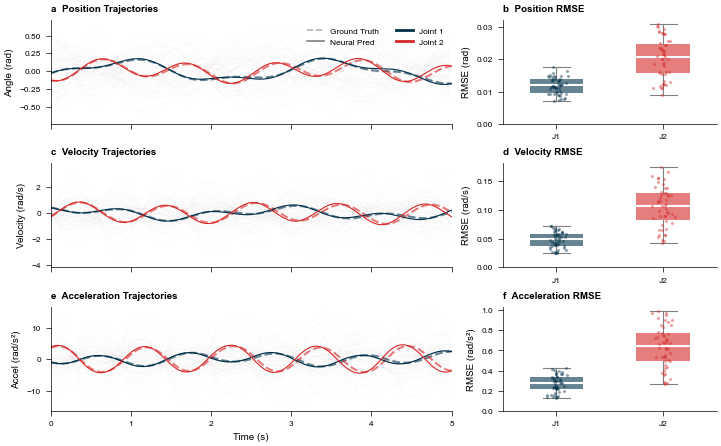

In [271]:
# Load previously saved simulation results
filename = save_filename

# Apply Nature-style figure settings globally
single_col, double_col, golden_ratio = set_nature_style()

# Load simulation results from disk
print(f"Loading results from {filename}...")
data = torch.load(filename, map_location='cpu')

# Extract time vector and RMSE metrics
t = data['trial_time']
rmse_pos = data['rmse_pos']
rmse_vel = data['rmse_vel']
rmse_acc = data['rmse_acc']

# Extract full predicted and true trajectories
pred_q   = data['all_pred_q']
true_q   = data['all_true_q']
pred_dq  = data['all_pred_dq']
true_dq  = data['all_true_dq']
pred_ddq = data['all_pred_ddq']
true_ddq = data['all_true_ddq']

# Demo trial index and downsampling for plotting
demo_idx = 0
step_slice = slice(None, None, 10)
COLOR_J1 = '#003049'
COLOR_J2 = '#d62828'

# Function to plot trajectories with spaghetti + demo trial overlay
def plot_trajectory_panel(ax, all_pred, single_true, single_pred, title, ylabel):
    t_plot = t[step_slice].tolist()
    for i in range(len(all_pred)):  # spaghetti
        ax.plot(t_plot, all_pred[i, step_slice, 0].tolist(), color=COLOR_J1, lw=0.1, alpha=0.05)
        ax.plot(t_plot, all_pred[i, step_slice, 1].tolist(), color=COLOR_J2, lw=0.1, alpha=0.05)
    ax.plot(t.tolist(), single_true[:, 0].tolist(), color=COLOR_J1, ls='--', lw=1.5, alpha=0.6)
    ax.plot(t.tolist(), single_true[:, 1].tolist(), color=COLOR_J2, ls='--', lw=1.5, alpha=0.6)
    ax.plot(t.tolist(), single_pred[:, 0].tolist(), color=COLOR_J1, ls='-', lw=0.8)
    ax.plot(t.tolist(), single_pred[:, 1].tolist(), color=COLOR_J2, ls='-', lw=0.8)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, float(t.max()))

# Function to plot RMSE boxplots with jittered points
def plot_stats_panel(ax, data_tensor, title, ylabel):
    data_list = [data_tensor[:, 0].tolist(), data_tensor[:, 1].tolist()]
    colors = [COLOR_J1, COLOR_J2]
    bp = ax.boxplot(data_list, positions=[1, 2], widths=0.5,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='white', linewidth=1.5),
                    boxprops=dict(linewidth=0),
                    whiskerprops=dict(color='gray', linewidth=0.8),
                    capprops=dict(color='gray', linewidth=0.8))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    num_points = data_tensor.shape[0]  # jitter points
    jitter1 = (torch.randn(num_points) * 0.04).tolist()
    jitter2 = (torch.randn(num_points) * 0.04).tolist()
    ax.scatter([1 + j for j in jitter1], data_tensor[:, 0].tolist(), color=COLOR_J1, s=2, alpha=0.3, zorder=3)
    ax.scatter([2 + j for j in jitter2], data_tensor[:, 1].tolist(), color=COLOR_J2, s=2, alpha=0.3, zorder=3)
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['J1', 'J2'])
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Figure dimensions using double column width and golden ratio
fig_width = double_col
fig_height = double_col * golden_ratio
fig, axs = plt.subplots(3, 2,
                        figsize=(fig_width, fig_height),
                        constrained_layout=True,
                        gridspec_kw={'width_ratios': [1.5, 0.8], 'height_ratios': [1, 1, 1]})

# Row 1: Position
plot_trajectory_panel(axs[0,0], pred_q, true_q[demo_idx], pred_q[demo_idx],
                      "a  Position Trajectories", "Angle (rad)")
plot_stats_panel(axs[0,1], rmse_pos, "b  Position RMSE", "RMSE (rad)")
axs[0,0].set_xticklabels([])

# Row 2: Velocity
plot_trajectory_panel(axs[1,0], pred_dq, true_dq[demo_idx], pred_dq[demo_idx],
                      "c  Velocity Trajectories", "Velocity (rad/s)")
plot_stats_panel(axs[1,1], rmse_vel, "d  Velocity RMSE", "RMSE (rad/s)")
axs[1,0].set_xticklabels([])

# Row 3: Acceleration
plot_trajectory_panel(axs[2,0], pred_ddq, true_ddq[demo_idx], pred_ddq[demo_idx],
                      "e  Acceleration Trajectories", "Accel (rad/s²)")
plot_stats_panel(axs[2,1], rmse_acc, "f  Acceleration RMSE", "RMSE (rad/s²)")
axs[2,0].set_xlabel("Time (s)")

# Global legend
legend_elements = [
    Line2D([0], [0], color='gray', lw=1.2, ls='--', alpha=0.6, label='Ground Truth'),
    Line2D([0], [0], color='gray', lw=1.2, ls='-', label='Neural Pred'),
    Line2D([0], [0], color=COLOR_J1, lw=2.0, label='Joint 1'),
    Line2D([0], [0], color=COLOR_J2, lw=2.0, label='Joint 2')
]
axs[0,0].legend(handles=legend_elements, loc='upper right', frameon=False, ncol=2)

# Save and display figure
plt.savefig('FIG_full_kinematics.svg', format='svg', transparent=True)
print(f"Saved to FIG_full_kinematics.svg with size ({fig_width:.2f}, {fig_height:.2f}) inches.")
plt.show()


We then quantify the computational overhead of our optimization pipeline relative to a regularly used forward dynamics solver.

In [272]:
print(f"Loading statistical data from {timing_filename}...")
data = torch.load(timing_filename, map_location='cpu')

import scipy.stats as scipy_stats

times_true = data['t_gen_true_per_traj'].to(dtype=TORCH_DTYPE)
times_sim = data['t_gen_sim_per_traj'].to(dtype=TORCH_DTYPE)
times_true_list = times_true.tolist()
times_sim_list = times_sim.tolist()

print(f"Data loaded: {len(times_true)} trajectories.")
print(f"Mean Time (Ground Truth): {times_true.mean().item():.4f} s")
print(f"Mean Time (Neural Sim):   {times_sim.mean().item():.4f} s")

print("\n" + '=' * 40)
print('1. NORMALITY CHECK (Shapiro-Wilk)')
print('=' * 40)

stat_true, p_true = scipy_stats.shapiro(times_true_list)
stat_sim, p_sim = scipy_stats.shapiro(times_sim_list)

is_normal_true = p_true > 0.05
is_normal_sim = p_sim > 0.05

print(f"Ground Truth Dist: p={p_true:.4e} [{'Normal' if is_normal_true else 'Not Normal'}]")
print(f"Neural Sim Dist:   p={p_sim:.4e} [{'Normal' if is_normal_sim else 'Not Normal'}]")

print("\n" + '=' * 40)
print('2. SIGNIFICANCE TEST (Sim > True?)')
print('=' * 40)

if is_normal_true and is_normal_sim:
    print('Using Independent T-Test (Parametric)...')
    test_type = 'T-Test'
    stat, p_val = scipy_stats.ttest_ind(times_sim_list, times_true_list, alternative='greater')
else:
    print('Using Mann-Whitney U Test (Non-Parametric)...')
    test_type = 'Mann-Whitney U'
    stat, p_val = scipy_stats.mannwhitneyu(times_sim_list, times_true_list, alternative='greater')

print(f"Test Statistic: {stat:.4f}")
print(f"P-Value:        {p_val:.4e}")

if p_val < 0.05:
    print('\nRESULT: SIGNIFICANT. The Neural Simulation takes significantly more time than Ground Truth generation.')
else:
    print('\nRESULT: NOT SIGNIFICANT. No statistical difference found.')

p_value_result = p_val
test_name_result = test_type


Loading statistical data from timing_stats.pt...
Data loaded: 50 trajectories.
Mean Time (Ground Truth): 0.3689 s
Mean Time (Neural Sim):   5.6214 s

1. NORMALITY CHECK (Shapiro-Wilk)
Ground Truth Dist: p=2.1988e-15 [Not Normal]
Neural Sim Dist:   p=2.6553e-14 [Not Normal]

2. SIGNIFICANCE TEST (Sim > True?)
Using Mann-Whitney U Test (Non-Parametric)...
Test Statistic: 2500.0000
P-Value:        3.5330e-18

RESULT: SIGNIFICANT. The Neural Simulation takes significantly more time than Ground Truth generation.


Following the calcualtions of the dealys, we visualize them.

Figure saved to FIG_timing_comparison.svg


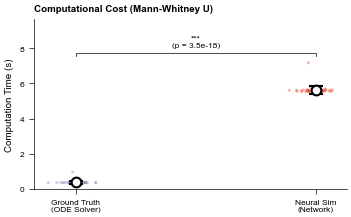

In [273]:
# Create single-column Nature-style figure for timing comparison
fig, ax = plt.subplots(
    figsize=(single_col, single_col * golden_ratio),
    constrained_layout=True,
)

data_to_plot = [times_true, times_sim]
labels = ['Ground Truth\n(ODE Solver)', 'Neural Sim\n(Network)']
colors = ['#8491B4', '#E64B35']

for i, data_arr in enumerate(data_to_plot):
    y = data_arr.to(dtype=TORCH_DTYPE)
    x = torch.normal(
        mean=torch.full((y.numel(),), float(i + 1), dtype=TORCH_DTYPE),
        std=0.04,
    )
    ax.scatter(x.tolist(), y.tolist(), color=colors[i], alpha=0.4, s=5, zorder=2, edgecolors='none')

means = [data_arr.mean().item() for data_arr in data_to_plot]
stds = [data_arr.std().item() for data_arr in data_to_plot]

for i, (mean, std) in enumerate(zip(means, stds)):
    ax.errorbar(
        i + 1,
        mean,
        yerr=std,
        fmt='o',
        color='black',
        ecolor='black',
        elinewidth=1.5,
        capsize=5,
        capthick=1.5,
        markersize=7,
        markerfacecolor='white',
        markeredgewidth=1.5,
        zorder=4,
    )

y_max = torch.maximum(times_true.max(), times_sim.max()).item()
y_bracket_start = y_max * 1.05
y_bracket_mid = y_max * 1.08
y_text_pos = y_max * 1.12

ax.plot([1, 1, 2, 2], [y_bracket_start, y_bracket_mid, y_bracket_mid, y_bracket_start], lw=0.5, c='black')

if p_value_result < 0.001:
    sig_str = '***'
elif p_value_result < 0.01:
    sig_str = '**'
elif p_value_result < 0.05:
    sig_str = '*'
else:
    sig_str = 'n.s.'

ax.text(1.5, y_text_pos, f"{sig_str}\n(p = {p_value_result:.1e})", ha='center', va='bottom', fontsize=6)

ax.set_ylabel('Computation Time (s)')
ax.set_title(f'Computational Cost ({test_name_result})', loc='left', fontweight='bold')
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_ylim(0, y_text_pos * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

save_path = 'FIG_timing_comparison.svg'
plt.savefig(save_path)
print(f"Figure saved to {save_path}")
plt.show()


Finally, we measure the per-step computational cost of the optimization procedure.

Figure saved to FIG_neural_latency_boxplot_clean.svg


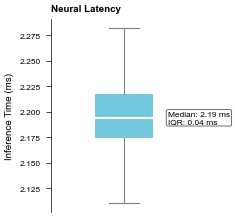

In [274]:
# Load neural timing data and convert to milliseconds
timing_filename = 'timing_stats.pt'
data = torch.load(timing_filename, map_location='cpu')
times_ms = data['t_neural_calls_all'].to(dtype=TORCH_DTYPE) * 1000.0

quantiles = torch.quantile(
    times_ms,
    torch.tensor([0.25, 0.75], dtype=TORCH_DTYPE),
)
median_val = torch.median(times_ms).item()
q1 = quantiles[0].item()
q3 = quantiles[1].item()
iqr = q3 - q1

fig, ax = plt.subplots(
    figsize=(single_col / 1.5, single_col * golden_ratio),
    constrained_layout=True,
)

bp = ax.boxplot(
    times_ms.tolist(),
    positions=[1],
    widths=0.4,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='white', linewidth=1.5),
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color='gray', linewidth=0.8),
    capprops=dict(color='gray', linewidth=0.8),
)

bp['boxes'][0].set_facecolor('#4DBBD5')
bp['boxes'][0].set_alpha(0.8)

stats_text = f"Median: {median_val:.2f} ms\nIQR: {iqr:.2f} ms"
ax.text(
    1.3,
    median_val,
    stats_text,
    fontsize=6,
    verticalalignment='center',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, linewidth=0.5),
)

ax.set_ylabel('Inference Time (ms)')
ax.set_title('Neural Latency', loc='left', fontweight='bold')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

save_path = 'FIG_neural_latency_boxplot_clean.svg'
plt.savefig(save_path)
print(f"Figure saved to {save_path}")
plt.show()


# Section 6: Hardware description

In the last brief section, we record the system configuration to document for reproducibility.

In [275]:
def get_hw_info():
    # System RAM
    ram_bytes = psutil.virtual_memory().total
    ram_gb = f"{round(ram_bytes / (1024**3), 1)}GB"

    # CPU Model
    try:
        # Run lscpu command to get the specific model name
        command = "cat /proc/cpuinfo | grep 'model name' | head -1"
        cpu_info = subprocess.check_output(command, shell=True).decode().strip()
        # Clean up string (remove "model name : ")
        cpu_model = cpu_info.split(":")[1].strip()
    except Exception:
        cpu_model = "Unknown CPU"

    # GPU & VRAM & CUDA
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        vram_bytes = torch.cuda.get_device_properties(0).total_memory
        vram_gb = f"{round(vram_bytes / (1024**3), 1)}GB"
        cuda_version = torch.version.cuda
    else:
        gpu_name = "None"
        vram_gb = "0GB"
        cuda_version = "N/A"

    # Software Versions
    python_version = sys.version.split()[0]
    pytorch_version = torch.__version__

    # Generate the Paragraph
    paragraph = (
        f"Network training was conducted on the Google Colab platform. "
        f"The system was equipped with a {gpu_name} GPU ({vram_gb} VRAM), "
        f"a {cpu_model} CPU, and {ram_gb} of system RAM. "
        f"We used Python {python_version}, PyTorch {pytorch_version}, "
        f"and CUDA {cuda_version} for model training."
    )

    return paragraph

# Run and print
print(get_hw_info())

Network training was conducted on the Google Colab platform. The system was equipped with a None GPU (0GB VRAM), a Unknown CPU CPU, and 32.0GB of system RAM. We used Python 3.13.11, PyTorch 2.11.0, and CUDA N/A for model training.


cat: /proc/cpuinfo: No such file or directory


The end!